<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/neqsim_ecalc_integrated_energy_emissions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim + eCalc: process, compressor maps, offshore energy, and emissions

This notebook demonstrates a traceable bridge between a detailed NeqSim oil-and-gas process
simulation and eCalc energy and greenhouse-gas accounting. NeqSim calculates phase behaviour,
separation, recompression, export compression, equipment duties, complete variable-speed
compressor maps, wind allocation, and battery operation. eCalc consumes the generated equipment
characteristics and time series to calculate fuel use, direct CO₂ emissions, cumulative energy,
capacity flags, recirculation losses, and hydrocarbon-export intensity.

The case is synthetic and educational. It is intended for concept screening, method development,
and teaching—not equipment selection, emissions reporting, or design certification.

## Learning objectives

After completing the notebook, you can:

1. build a three-pressure oil, gas, and water separation train in NeqSim;
2. connect low-pressure, medium-pressure, and 70-to-160 bara export compression;
3. close material and compressor-energy balances;
4. generate all speed, head, and efficiency curves for all three compressors;
5. generate and inspect explicit surge and stonewall boundaries;
6. transfer the complete compressor maps to eCalc variable-speed compressor models;
7. generate an eCalc generator-set fuel curve from a NeqSim gas-turbine model;
8. run a ten-year field-depletion study with declining inlet pressure;
9. quantify incremental production, compressor constraints, fuel, and CO₂;
9. use NeqSim energy buses and battery storage for wind–gas–battery dispatch;
10. send residual gas-turbine load to eCalc for auditable fuel and CO₂ bookkeeping; and
11. compare NeqSim and eCalc results, sensitivities, limitations, and decision metrics.

## 1. Division of responsibility

The combination is valuable because the two tools solve different layers of the same problem.

| Layer | NeqSim responsibility | eCalc responsibility |
|---|---|---|
| Fluid | compositional SRK phase equilibrium | documented compressor fluid model |
| Process | separators, valves, mixers, compressors, coolers | long-term consumer topology |
| Machinery | generated speed–head–efficiency maps and operating margins | chart-based power, ASV loss, capacity flags |
| Power system | wind allocation, firm gas capacity, native battery state | fuel conversion and emissions bookkeeping |
| Time | detailed operating points and hourly dispatch | cumulative energy, fuel, CO₂, and intensity |

The bridge preserves engineering meaning:

$$
\text{fluid and process state}
\rightarrow
\text{equipment map and duty}
\rightarrow
\text{energy dispatch}
\rightarrow
\text{fuel and emissions account}
$$

## 2. Model boundaries and assumptions

- All pressures are absolute.
- NeqSim uses the SRK equation of state with the classic mixing rule.
- The inlet is a synthetic three-phase wellstream at 70 bara and 65 °C.
- Separation pressures are 70, 25, and 8 bara.
- Recompression targets are 25 and 70 bara; export pressure is 160 bara.
- Compressor maps are generated from the converged design point with seven speed lines.
- Reynolds, Mach/stonewall, and multistage surge corrections are enabled.
- A 10% eCalc control margin is applied to the map-derived surge line.
- A fixed 8 MW utility and hotel load is added outside the process model.
- Wind is synthetic and deterministic; no measured data are implied.
- Battery charge and discharge efficiencies are each 95%.
- Direct offshore CO₂ is reported. Scope 2, construction, and lifecycle emissions are excluded.

For a compressor, the shaft-duty check is:

$$
\dot W = \dot m \left(h_2-h_1\right)
$$

The operating margins are:

$$
M_{\mathrm{surge}} =
100\frac{Q-Q_{\mathrm{surge}}}{Q_{\mathrm{surge}}}
$$

$$
M_{\mathrm{stonewall}} =
100\frac{Q_{\mathrm{stonewall}}-Q}{Q_{\mathrm{stonewall}}}
$$

Positive values place the operating point between the two boundaries.

## 3. Clean Colab setup

The notebook pins the versions used for the retained results. The installation runs only when the
required versions are not already available, which keeps repeated execution fast.

In [1]:
from importlib.metadata import PackageNotFoundError, version
import subprocess
import sys

required_versions = {
    "neqsim": "3.16.0",
    "libecalc": "13.9.0",
}
missing_or_wrong = []
for package_name, required_version in required_versions.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        missing_or_wrong.append(f"{package_name}=={required_version}")

if missing_or_wrong:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *missing_or_wrong,
        ],
        check=True,
    )
    print("Installed:", ", ".join(missing_or_wrong))
else:
    print("Pinned NeqSim and eCalc versions are already installed.")

Pinned NeqSim and eCalc versions are already installed.


In [2]:
from importlib.metadata import version
from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-ecalc-matplotlib")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from neqsim import jneqsim

VERSIONS = {
    "Python": sys.version.split()[0],
    "NeqSim": version("neqsim"),
    "eCalc": version("libecalc"),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
}
display(pd.Series(VERSIONS, name="Version").to_frame())

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "lp": "#009E73",
    "mp": "#0072B2",
    "export": "#D55E00",
    "wind": "#56B4E9",
    "battery": "#009E73",
    "gas": "#D55E00",
    "load": "#222222",
}

,Version
Python,3.12.13
NeqSim,3.16.0
eCalc,13.9.0
NumPy,2.5.1
pandas,3.0.5


## 4. Integrated workflow

The same process results are used twice: first to generate equipment models for a long-term eCalc
prognosis, and then to create an hourly load profile for NeqSim energy dispatch.

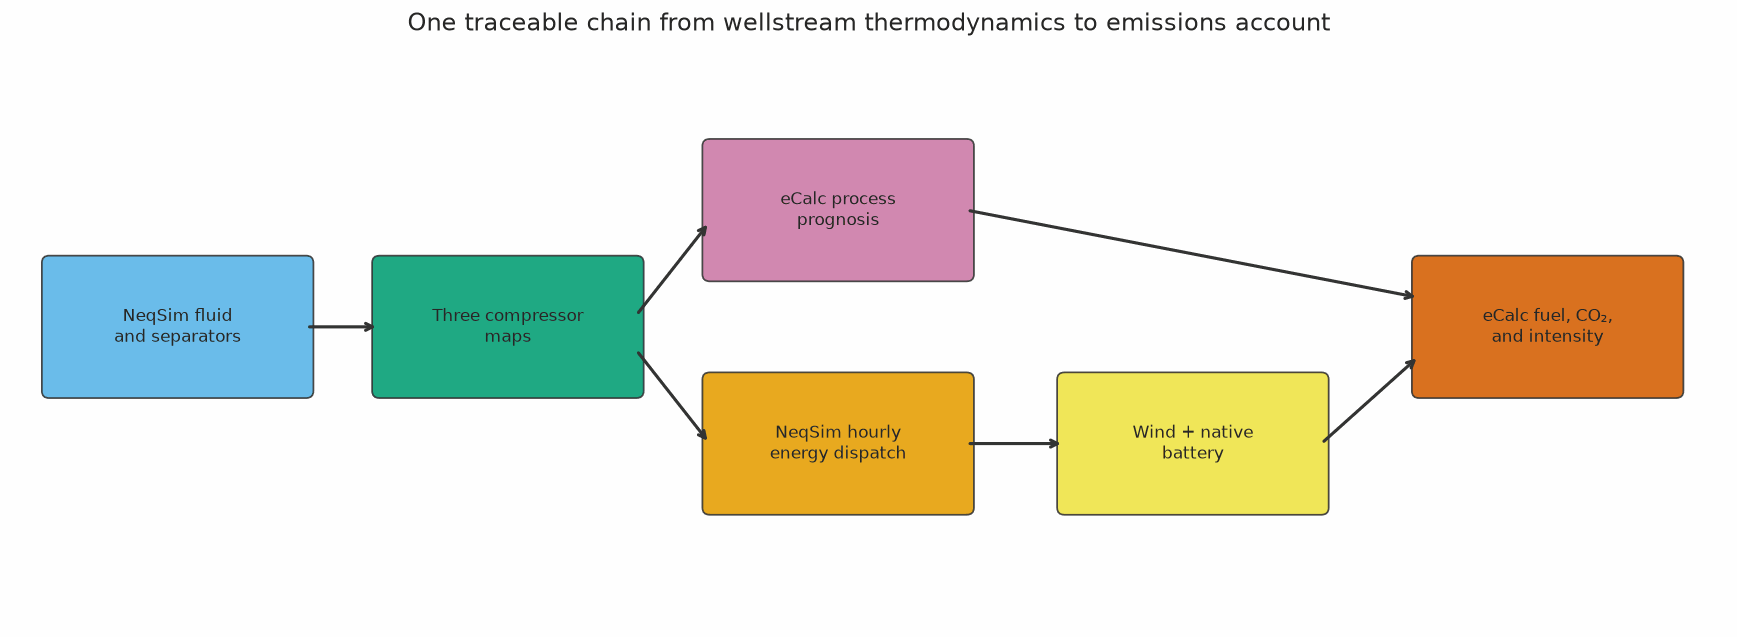

In [3]:
figure, axis = plt.subplots(figsize=(14.0, 5.2))
axis.set_xlim(0.0, 14.0)
axis.set_ylim(0.0, 5.0)
axis.axis("off")

boxes = [
    (0.3, 2.0, 2.1, "NeqSim fluid\nand separators", "#56B4E9"),
    (3.0, 2.0, 2.1, "Three compressor\nmaps", "#009E73"),
    (5.7, 3.0, 2.1, "eCalc process\nprognosis", "#CC79A7"),
    (5.7, 1.0, 2.1, "NeqSim hourly\nenergy dispatch", "#E69F00"),
    (8.6, 1.0, 2.1, "Wind + native\nbattery", "#F0E442"),
    (11.5, 2.0, 2.1, "eCalc fuel, CO₂,\nand intensity", "#D55E00"),
]
for x_value, y_value, width, label, color in boxes:
    patch = FancyBboxPatch(
        (x_value, y_value),
        width,
        1.1,
        boxstyle="round,pad=0.06",
        facecolor=color,
        edgecolor="#333333",
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_value + width / 2.0,
        y_value + 0.55,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

arrows = [
    ((2.4, 2.55), (3.0, 2.55)),
    ((5.1, 2.65), (5.7, 3.45)),
    ((5.1, 2.35), (5.7, 1.55)),
    ((7.8, 1.55), (8.6, 1.55)),
    ((7.8, 3.55), (11.5, 2.8)),
    ((10.7, 1.55), (11.5, 2.3)),
]
for start, stop in arrows:
    axis.annotate(
        "",
        xy=stop,
        xytext=start,
        arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#333333"},
    )

axis.set_title(
    "One traceable chain from wellstream thermodynamics to emissions account",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## 5. Process definition

The synthetic composition contains gas, condensate/oil-range components, and water. Mole fractions
sum to unity before NeqSim receives the fluid. Heavy components are needed to create meaningful
liquid dropout through the pressure stages.

In [4]:
WELLSTREAM_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.600,
    "ethane": 0.080,
    "propane": 0.065,
    "i-butane": 0.025,
    "n-butane": 0.035,
    "i-pentane": 0.020,
    "n-pentane": 0.020,
    "n-hexane": 0.025,
    "n-heptane": 0.035,
    "n-octane": 0.025,
    "nC10": 0.025,
    "water": 0.015,
}

BASE_FEED_KG_H = 180_000.0
FEED_TEMPERATURE_C = 65.0
HP_PRESSURE_BARA = 70.0
MP_PRESSURE_BARA = 25.0
LP_PRESSURE_BARA = 8.0
EXPORT_PRESSURE_BARA = 160.0
AFTERCOOLER_TEMPERATURE_C = 35.0
FIXED_UTILITY_LOAD_MW = 8.0

composition_table = pd.DataFrame(
    {
        "Component": list(WELLSTREAM_COMPOSITION),
        "Mole fraction": list(WELLSTREAM_COMPOSITION.values()),
    }
)
display(composition_table)
print(
    "Composition sum:",
    f"{sum(WELLSTREAM_COMPOSITION.values()):.12f}",
)

Composition sum: 1.000000000000


,Component,Mole fraction
0,nitrogen,0.010
1,CO2,0.020
2,methane,0.600
3,ethane,0.080
4,propane,0.065
5,i-butane,0.025
6,n-butane,0.035
7,i-pentane,0.020
8,n-pentane,0.020
9,n-hexane,0.025


In [5]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Mixer = jneqsim.process.equipment.mixer.Mixer
CompressorChartGenerator = (
    jneqsim.process.equipment.compressor.CompressorChartGenerator
)


def make_wellstream(flow_kg_h, inlet_pressure_bara=HP_PRESSURE_BARA):
    fluid = SystemSrkEos(
        FEED_TEMPERATURE_C + 273.15,
        inlet_pressure_bara,
    )
    for component_name, mole_fraction in WELLSTREAM_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    return fluid


def build_process_case(
    flow_kg_h=BASE_FEED_KG_H,
    hp_pressure_bara=HP_PRESSURE_BARA,
    mp_pressure_bara=MP_PRESSURE_BARA,
    lp_pressure_bara=LP_PRESSURE_BARA,
):
    feed = Stream(
        "wellstream feed",
        make_wellstream(flow_kg_h, hp_pressure_bara),
    )
    hp_separator = Separator("HP separator", feed)

    hp_liquid_valve = ThrottlingValve(
        "HP-to-MP liquid valve",
        hp_separator.getLiquidOutStream(),
    )
    hp_liquid_valve.setOutletPressure(mp_pressure_bara, "bara")
    mp_separator = Separator(
        "MP separator",
        hp_liquid_valve.getOutletStream(),
    )

    mp_liquid_valve = ThrottlingValve(
        "MP-to-LP liquid valve",
        mp_separator.getLiquidOutStream(),
    )
    mp_liquid_valve.setOutletPressure(lp_pressure_bara, "bara")
    lp_separator = Separator(
        "LP separator",
        mp_liquid_valve.getOutletStream(),
    )

    lp_compressor = Compressor(
        "LP flash-gas compressor",
        lp_separator.getGasOutStream(),
    )
    lp_compressor.setOutletPressure(mp_pressure_bara, "bara")
    lp_compressor.setUsePolytropicCalc(True)
    lp_compressor.setPolytropicEfficiency(0.76)
    lp_compressor.setSpeed(10_000.0)
    lp_aftercooler = Cooler(
        "LP compressor aftercooler",
        lp_compressor.getOutletStream(),
    )
    lp_aftercooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )

    mp_mixer = Mixer("MP gas mixer")
    mp_mixer.addStream(mp_separator.getGasOutStream())
    mp_mixer.addStream(lp_aftercooler.getOutletStream())
    mp_compressor = Compressor(
        "MP gas compressor",
        mp_mixer.getOutletStream(),
    )
    mp_compressor.setOutletPressure(hp_pressure_bara, "bara")
    mp_compressor.setUsePolytropicCalc(True)
    mp_compressor.setPolytropicEfficiency(0.78)
    mp_compressor.setSpeed(10_000.0)
    mp_aftercooler = Cooler(
        "MP compressor aftercooler",
        mp_compressor.getOutletStream(),
    )
    mp_aftercooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )

    export_mixer = Mixer("export gas mixer")
    export_mixer.addStream(hp_separator.getGasOutStream())
    export_mixer.addStream(mp_aftercooler.getOutletStream())
    export_compressor = Compressor(
        "HP-to-160 bara export compressor",
        export_mixer.getOutletStream(),
    )
    export_compressor.setOutletPressure(EXPORT_PRESSURE_BARA, "bara")
    export_compressor.setUsePolytropicCalc(True)
    export_compressor.setPolytropicEfficiency(0.79)
    export_compressor.setSpeed(10_000.0)
    export_aftercooler = Cooler(
        "export gas aftercooler",
        export_compressor.getOutletStream(),
    )
    export_aftercooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )

    units = [
        feed,
        hp_separator,
        hp_liquid_valve,
        mp_separator,
        mp_liquid_valve,
        lp_separator,
        lp_compressor,
        lp_aftercooler,
        mp_mixer,
        mp_compressor,
        mp_aftercooler,
        export_mixer,
        export_compressor,
        export_aftercooler,
    ]
    return {
        "units": units,
        "feed": feed,
        "hp_separator": hp_separator,
        "mp_separator": mp_separator,
        "lp_separator": lp_separator,
        "hp_liquid_valve": hp_liquid_valve,
        "mp_liquid_valve": mp_liquid_valve,
        "lp_compressor": lp_compressor,
        "mp_compressor": mp_compressor,
        "export_compressor": export_compressor,
        "lp_aftercooler": lp_aftercooler,
        "mp_aftercooler": mp_aftercooler,
        "export_aftercooler": export_aftercooler,
        "mp_mixer": mp_mixer,
        "export_mixer": export_mixer,
    }


def run_process_case(case):
    for unit in case["units"]:
        unit.run()
    return case


base_case = run_process_case(build_process_case())
print("Base process converged through", len(base_case["units"]), "units.")

Base process converged through 14 units.


## 6. Base process results

The export gas is the sum of high-pressure separator gas and recompressed flash gas. The final
stable liquid remains at 8 bara. Therefore, a compact overall mass check is:

$$
\dot m_{\mathrm{feed}} =
\dot m_{\mathrm{export\ gas}} +
\dot m_{\mathrm{stable\ liquid}}
$$

In [6]:
def compressor_energy_row(compressor):
    inlet = compressor.getInletStream()
    outlet = compressor.getOutletStream()
    mass_flow_kg_s = inlet.getFlowRate("kg/sec")
    inlet_h_j_kg = inlet.getFluid().getEnthalpy("J/kg")
    outlet_h_j_kg = outlet.getFluid().getEnthalpy("J/kg")
    enthalpy_power_w = mass_flow_kg_s * (
        outlet_h_j_kg - inlet_h_j_kg
    )
    compressor_power_w = compressor.getPower("W")
    return {
        "Compressor": str(compressor.getName()),
        "Inlet pressure [bara]": inlet.getPressure("bara"),
        "Outlet pressure [bara]": outlet.getPressure("bara"),
        "Flow [kg/h]": inlet.getFlowRate("kg/hr"),
        "Power [MW]": compressor_power_w / 1.0e6,
        "Polytropic head [kJ/kg]": compressor.getPolytropicHead(
            "kJ/kg"
        ),
        "Polytropic efficiency [%]": (
            100.0 * compressor.getPolytropicEfficiency()
        ),
        "Energy residual [W]": enthalpy_power_w - compressor_power_w,
    }


compressors = {
    "LP": base_case["lp_compressor"],
    "MP": base_case["mp_compressor"],
    "Export": base_case["export_compressor"],
}
compressor_base_table = pd.DataFrame(
    [compressor_energy_row(item) for item in compressors.values()]
)
display(compressor_base_table.round(6))

feed_mass_kg_h = base_case["feed"].getFlowRate("kg/hr")
export_mass_kg_h = base_case[
    "export_aftercooler"
].getOutletStream().getFlowRate("kg/hr")
stable_liquid_kg_h = base_case[
    "lp_separator"
].getLiquidOutStream().getFlowRate("kg/hr")
mass_residual_kg_h = (
    feed_mass_kg_h - export_mass_kg_h - stable_liquid_kg_h
)
total_compressor_power_mw = compressor_base_table["Power [MW]"].sum()

base_summary = pd.Series(
    {
        "Feed [kg/h]": feed_mass_kg_h,
        "Export gas [kg/h]": export_mass_kg_h,
        "Stable liquid [kg/h]": stable_liquid_kg_h,
        "Mass residual [kg/h]": mass_residual_kg_h,
        "LP + MP + export power [MW]": total_compressor_power_mw,
        "Total electrical load incl. utilities [MW]": (
            total_compressor_power_mw + FIXED_UTILITY_LOAD_MW
        ),
        "Export pressure [bara]": base_case[
            "export_compressor"
        ].getOutletStream().getPressure("bara"),
        "Export temperature [°C]": base_case[
            "export_aftercooler"
        ].getOutletStream().getTemperature("C"),
    },
    name="Base case",
)
display(base_summary.to_frame())

,Compressor,Inlet pressure [bara],Outlet pressure [bara],Flow [kg/h],Power [MW],Polytropic head [kJ/kg],Polytropic efficiency [%],Energy residual [W]
0,LP flash-gas compressor,8.0,25.0,5450.066138,0.191422,96.096107,76.0,0.0
1,MP gas compressor,25.0,70.0,15168.065561,0.520389,96.337475,78.0,-0.0
2,HP-to-160 bara export compressor,70.0,160.0,96749.381195,3.228849,94.913738,79.0,0.0


,Base case
Feed [kg/h],1.800000e+05
Export gas [kg/h],9.674938e+04
Stable liquid [kg/h],8.325062e+04
Mass residual [kg/h],8.585630e-09
LP + MP + export power [MW],3.940660e+00
Total electrical load incl. utilities [MW],1.194066e+01
Export pressure [bara],1.600000e+02
Export temperature [°C],3.500000e+01


In [7]:
stream_rows = []
named_streams = {
    "Wellstream feed": base_case["feed"],
    "HP separator gas": base_case[
        "hp_separator"
    ].getGasOutStream(),
    "MP separator gas": base_case[
        "mp_separator"
    ].getGasOutStream(),
    "LP separator gas": base_case[
        "lp_separator"
    ].getGasOutStream(),
    "MP compressor inlet": base_case[
        "mp_compressor"
    ].getInletStream(),
    "Export compressor inlet": base_case[
        "export_compressor"
    ].getInletStream(),
    "Export gas product": base_case[
        "export_aftercooler"
    ].getOutletStream(),
    "Stable liquid": base_case[
        "lp_separator"
    ].getLiquidOutStream(),
}
for stream_name, stream in named_streams.items():
    stream_rows.append(
        {
            "Stream": stream_name,
            "Pressure [bara]": stream.getPressure("bara"),
            "Temperature [°C]": stream.getTemperature("C"),
            "Mass flow [kg/h]": stream.getFlowRate("kg/hr"),
            "Standard flow [Sm³/d]": stream.getFlowRate("Sm3/day"),
            "Phases": stream.getFluid().getNumberOfPhases(),
        }
    )

stream_table = pd.DataFrame(stream_rows)
display(stream_table.round(4))

,Stream,Pressure [bara],Temperature [°C],Mass flow [kg/h],Standard flow [Sm³/d],Phases
0,Wellstream feed,70.0,65.0000,180000.0000,2.937230e+06,3
1,HP separator gas,70.0,65.0000,81581.3156,2.054062e+06,1
2,MP separator gas,25.0,58.0187,9717.9994,2.182432e+05,1
3,LP separator gas,8.0,51.1031,5450.0661,9.343389e+04,1
4,MP compressor inlet,25.0,51.1182,15168.0656,3.116771e+05,3
5,Export compressor inlet,70.0,61.0476,96749.3812,2.365739e+06,3
6,Export gas product,160.0,35.0000,96749.3812,2.365739e+06,2
7,Stable liquid,8.0,51.1031,83250.6188,5.714908e+05,2


## 7. Generate complete compressor maps

The NeqSim `CompressorChartGenerator` anchors each map to the converged design point. Each map
contains seven speed lines and five points per speed line. The generator applies:

- fan-law flow and head scaling;
- Reynolds correction of efficiency;
- Mach-based stonewall correction; and
- multistage surge correction where requested.

The lowest-flow point on each speed line is the map surge boundary. The highest-flow point is the
stonewall boundary. These same arrays are later passed directly to eCalc.

In [8]:
map_settings = {
    "LP": {"stages": 1, "diameter_m": 0.45},
    "MP": {"stages": 2, "diameter_m": 0.60},
    "Export": {"stages": 2, "diameter_m": 0.85},
}
compressor_charts = {}
for machine_name, compressor in compressors.items():
    settings = map_settings[machine_name]
    generator = CompressorChartGenerator(compressor)
    generator.setChartType("interpolate and extrapolate")
    generator.setImpellerDiameter(settings["diameter_m"])
    generator.enableAdvancedCorrections(settings["stages"])
    chart = generator.generateCompressorChart("normal curves", 7)
    compressor.setCompressorChart(chart)
    compressor_charts[machine_name] = chart

run_process_case(base_case)
print("Generated and attached maps for:", ", ".join(compressor_charts))

Generated and attached maps for: LP, MP, Export


In [9]:
curve_records = []
for machine_name, chart in compressor_charts.items():
    speed_values = [float(value) for value in chart.getSpeeds()]
    flow_values = chart.getFlows()
    head_values = chart.getHeads()
    efficiency_values = chart.getPolytropicEfficiencies()
    for curve_index, speed_rpm in enumerate(speed_values):
        for point_index in range(len(flow_values[curve_index])):
            position = "interior"
            if point_index == 0:
                position = "surge boundary"
            elif point_index == len(flow_values[curve_index]) - 1:
                position = "stonewall boundary"
            curve_records.append(
                {
                    "Machine": machine_name,
                    "Speed [rpm]": speed_rpm,
                    "Point": point_index,
                    "Position": position,
                    "Actual flow [m³/h]": float(
                        flow_values[curve_index][point_index]
                    ),
                    "Head [kJ/kg]": float(
                        head_values[curve_index][point_index]
                    ),
                    "Efficiency [%]": float(
                        efficiency_values[curve_index][point_index]
                    ),
                }
            )

compressor_map_data = pd.DataFrame(curve_records)
map_summary = (
    compressor_map_data.groupby("Machine")
    .agg(
        speed_lines=("Speed [rpm]", "nunique"),
        points=("Point", "count"),
        minimum_flow=("Actual flow [m³/h]", "min"),
        maximum_flow=("Actual flow [m³/h]", "max"),
        minimum_head=("Head [kJ/kg]", "min"),
        maximum_head=("Head [kJ/kg]", "max"),
        minimum_efficiency=("Efficiency [%]", "min"),
        maximum_efficiency=("Efficiency [%]", "max"),
    )
)
display(map_summary.round(3))

,speed_lines,points,minimum_flow,maximum_flow,minimum_head,maximum_head,minimum_efficiency,maximum_efficiency
Machine,,,,,,,,
Export,7,35,746.241,2038.511,37.372,115.107,65.246,79.386
LP,7,35,276.324,773.707,37.838,116.541,62.768,76.372
MP,7,35,281.058,767.769,37.933,116.833,64.420,78.381


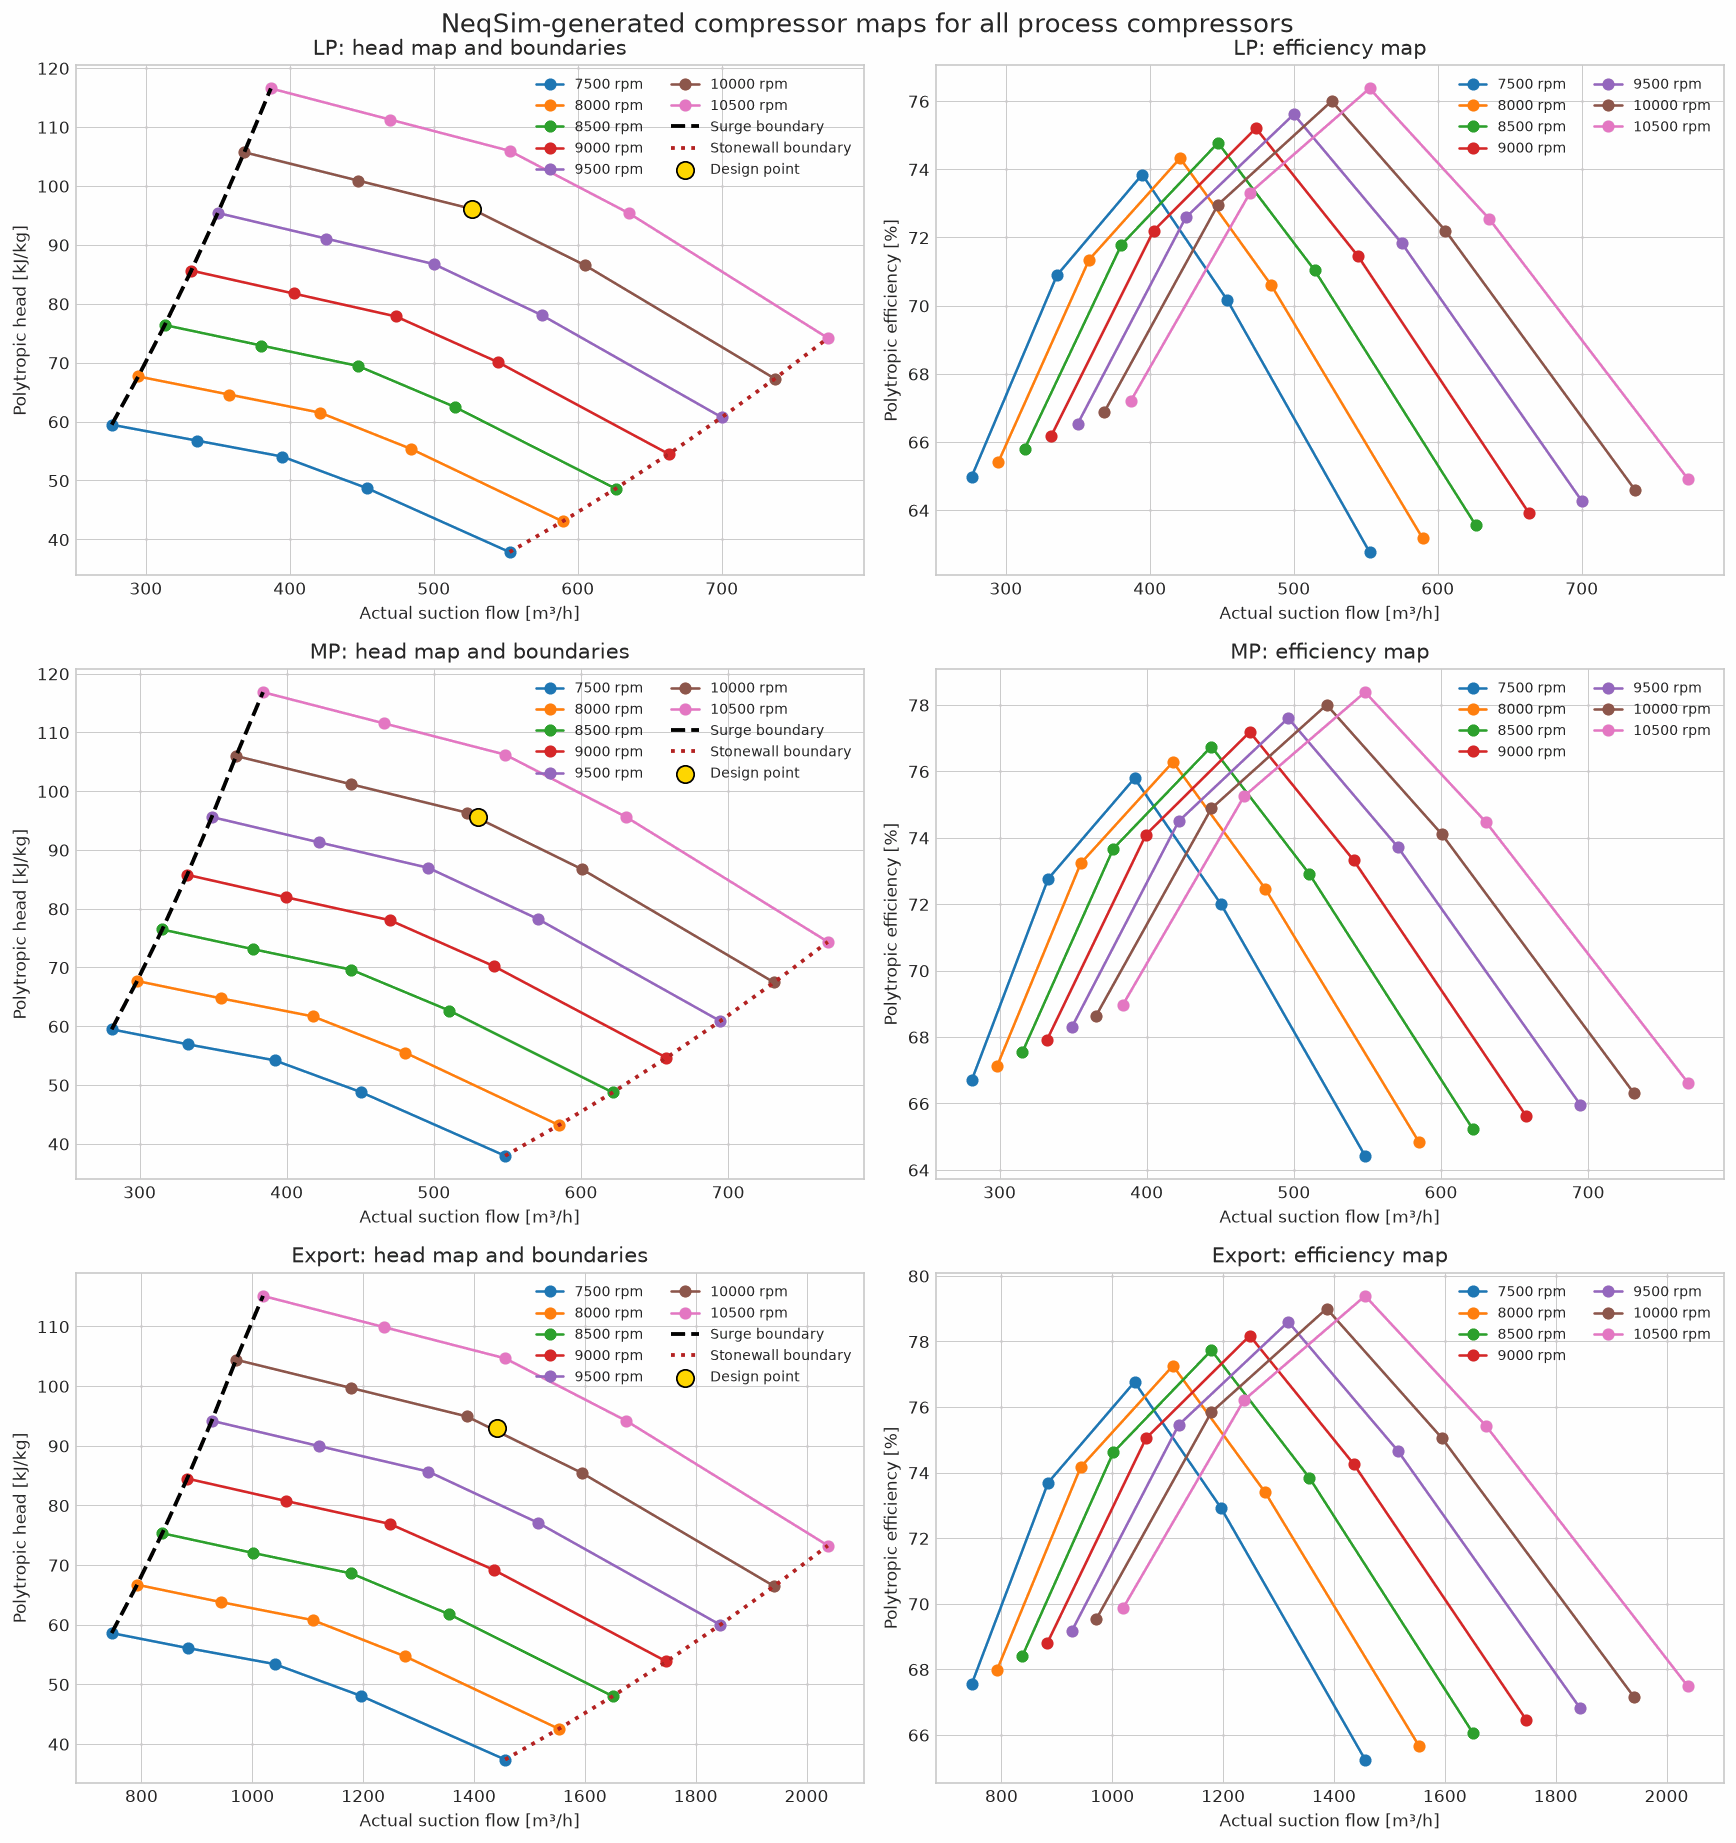

In [10]:
figure, axes = plt.subplots(3, 2, figsize=(14.0, 15.0))
for row_index, machine_name in enumerate(["LP", "MP", "Export"]):
    machine_data = compressor_map_data[
        compressor_map_data["Machine"] == machine_name
    ]
    head_axis = axes[row_index, 0]
    efficiency_axis = axes[row_index, 1]
    for speed_rpm, speed_data in machine_data.groupby("Speed [rpm]"):
        head_axis.plot(
            speed_data["Actual flow [m³/h]"],
            speed_data["Head [kJ/kg]"],
            marker="o",
            label=f"{speed_rpm:.0f} rpm",
        )
        efficiency_axis.plot(
            speed_data["Actual flow [m³/h]"],
            speed_data["Efficiency [%]"],
            marker="o",
            label=f"{speed_rpm:.0f} rpm",
        )

    surge_data = machine_data[
        machine_data["Position"] == "surge boundary"
    ]
    stonewall_data = machine_data[
        machine_data["Position"] == "stonewall boundary"
    ]
    head_axis.plot(
        surge_data["Actual flow [m³/h]"],
        surge_data["Head [kJ/kg]"],
        "k--",
        linewidth=2.2,
        label="Surge boundary",
    )
    head_axis.plot(
        stonewall_data["Actual flow [m³/h]"],
        stonewall_data["Head [kJ/kg]"],
        color="firebrick",
        linestyle=":",
        linewidth=2.2,
        label="Stonewall boundary",
    )

    compressor = compressors[machine_name]
    head_axis.scatter(
        [compressor.getInletStream().getFlowRate("m3/hr")],
        [compressor.getPolytropicHead("kJ/kg")],
        s=100,
        color="gold",
        edgecolor="black",
        zorder=5,
        label="Design point",
    )
    head_axis.set(
        title=f"{machine_name}: head map and boundaries",
        xlabel="Actual suction flow [m³/h]",
        ylabel="Polytropic head [kJ/kg]",
    )
    efficiency_axis.set(
        title=f"{machine_name}: efficiency map",
        xlabel="Actual suction flow [m³/h]",
        ylabel="Polytropic efficiency [%]",
    )
    head_axis.legend(ncol=2, fontsize=8)
    efficiency_axis.legend(ncol=2, fontsize=8)

figure.suptitle(
    "NeqSim-generated compressor maps for all process compressors",
    fontsize=15,
)
figure.tight_layout()
plt.show()

## 8. Design-point margins

The numerical margin table checks the plotted operating points. A design point inside the map must
have positive surge and stonewall margins and reproduce the requested discharge pressure.

In [11]:
design_margin_rows = []
for machine_name, compressor in compressors.items():
    chart = compressor_charts[machine_name]
    speed_rpm = compressor.getSpeed()
    actual_flow_m3_h = compressor.getInletStream().getFlowRate("m3/hr")
    surge_flow_m3_h = chart.getSurgeFlowAtSpeed(speed_rpm)
    stonewall_flow_m3_h = chart.getStoneWallFlowAtSpeed(speed_rpm)
    design_margin_rows.append(
        {
            "Machine": machine_name,
            "Speed [rpm]": speed_rpm,
            "Actual flow [m³/h]": actual_flow_m3_h,
            "Surge flow [m³/h]": surge_flow_m3_h,
            "Stonewall flow [m³/h]": stonewall_flow_m3_h,
            "Surge margin [%]": (
                100.0
                * (actual_flow_m3_h - surge_flow_m3_h)
                / surge_flow_m3_h
            ),
            "Stonewall margin [%]": (
                100.0
                * (stonewall_flow_m3_h - actual_flow_m3_h)
                / stonewall_flow_m3_h
            ),
            "Power [MW]": compressor.getPower("MW"),
        }
    )

design_margin_table = pd.DataFrame(design_margin_rows)
display(design_margin_table.round(4))

,Machine,Speed [rpm],Actual flow [m³/h],Surge flow [m³/h],Stonewall flow [m³/h],Surge margin [%],Stonewall margin [%],Power [MW]
0,LP,10000.0,526.3313,368.4319,736.8638,42.8571,28.5714,0.1914
1,MP,10000.0,529.9129,365.6043,731.2086,44.9417,27.5292,0.5173
2,Export,10000.0,1440.8134,970.7197,1941.4394,48.4273,25.7863,3.1797


## 9. Production-rate and operating-envelope sweep

The feed is varied from 55% to 115% of design. NeqSim solves compressor speed against the fixed
discharge-pressure target while enforcing the generated speed range of 7,500–10,500 rpm.

This sweep serves four purposes:

1. quantify how process duty changes with throughput;
2. identify surge, stonewall, and speed constraints;
3. generate time-series interpolation functions; and
4. provide operating points for comparison with eCalc.

In [12]:
target_pressures = {
    "LP": MP_PRESSURE_BARA,
    "MP": HP_PRESSURE_BARA,
    "Export": EXPORT_PRESSURE_BARA,
}
for machine_name, compressor in compressors.items():
    compressor.setOutletPressure(
        target_pressures[machine_name],
        "bara",
    )
    compressor.setSolveSpeed(True)
    compressor.setMinimumSpeed(7_500.0)
    compressor.setMaximumSpeed(10_500.0)
    compressor.setLimitSpeed(True)


def evaluate_machine(machine_name, compressor):
    chart = compressor_charts[machine_name]
    speed_rpm = compressor.getSpeed()
    actual_flow_m3_h = compressor.getInletStream().getFlowRate("m3/hr")
    surge_flow_m3_h = chart.getSurgeFlowAtSpeed(speed_rpm)
    stonewall_flow_m3_h = chart.getStoneWallFlowAtSpeed(speed_rpm)
    discharge_pressure_bara = compressor.getOutletStream().getPressure(
        "bara"
    )
    pressure_error_bara = (
        discharge_pressure_bara - target_pressures[machine_name]
    )
    surge_margin = (
        100.0
        * (actual_flow_m3_h - surge_flow_m3_h)
        / surge_flow_m3_h
    )
    stonewall_margin = (
        100.0
        * (stonewall_flow_m3_h - actual_flow_m3_h)
        / stonewall_flow_m3_h
    )
    return {
        "Machine": machine_name,
        "Standard rate [Sm³/d]": compressor.getInletStream().getFlowRate(
            "Sm3/day"
        ),
        "Actual rate [m³/h]": actual_flow_m3_h,
        "Speed [rpm]": speed_rpm,
        "Head [kJ/kg]": compressor.getPolytropicHead("kJ/kg"),
        "Efficiency [%]": 100.0 * compressor.getPolytropicEfficiency(),
        "Power [MW]": compressor.getPower("MW"),
        "Discharge pressure [bara]": discharge_pressure_bara,
        "Pressure error [bar]": pressure_error_bara,
        "Surge margin [%]": surge_margin,
        "Stonewall margin [%]": stonewall_margin,
        "Map feasible": (
            surge_margin > 0.0
            and stonewall_margin > 0.0
            and abs(pressure_error_bara) < 0.2
        ),
    }


feed_factors = np.linspace(0.55, 1.15, 13)
machine_sweep_rows = []
process_sweep_rows = []
for feed_factor in feed_factors:
    base_case["feed"].setFlowRate(
        BASE_FEED_KG_H * feed_factor,
        "kg/hr",
    )
    run_process_case(base_case)
    machine_rows = []
    for machine_name, compressor in compressors.items():
        result = evaluate_machine(machine_name, compressor)
        result["Feed factor"] = feed_factor
        machine_rows.append(result)
        machine_sweep_rows.append(result)

    total_power_mw = sum(row["Power [MW]"] for row in machine_rows)
    export_gas = base_case["export_aftercooler"].getOutletStream()
    stable_liquid = base_case[
        "lp_separator"
    ].getLiquidOutStream()
    process_sweep_rows.append(
        {
            "Feed factor": feed_factor,
            "Feed [kg/h]": BASE_FEED_KG_H * feed_factor,
            "Compressor power [MW]": total_power_mw,
            "Total load [MW]": total_power_mw + FIXED_UTILITY_LOAD_MW,
            "Export gas [Sm³/d]": export_gas.getFlowRate("Sm3/day"),
            "Stable liquid [kg/h]": stable_liquid.getFlowRate("kg/hr"),
            "All maps feasible": all(
                row["Map feasible"] for row in machine_rows
            ),
        }
    )

machine_sweep = pd.DataFrame(machine_sweep_rows)
process_sweep = pd.DataFrame(process_sweep_rows)
display(process_sweep.round(4))

,Feed factor,Feed [kg/h],Compressor power [MW],Total load [MW],Export gas [Sm³/d],Stable liquid [kg/h],All maps feasible
0,0.55,99000.0,2.6055,10.6055,1.301156e+06,45787.8403,False
1,0.60,108000.0,2.7376,10.7376,1.419443e+06,49950.3713,False
2,0.65,117000.0,2.8613,10.8613,1.537730e+06,54112.9022,False
3,0.70,126000.0,2.9749,10.9749,1.656017e+06,58275.4332,False
4,0.75,135000.0,3.0833,11.0833,1.774304e+06,62437.9641,True
5,0.80,144000.0,3.1904,11.1904,1.892591e+06,66600.4950,True
6,0.85,153000.0,3.3200,11.3200,2.010878e+06,70763.0260,True
7,0.90,162000.0,3.4470,11.4470,2.129165e+06,74925.5569,True
8,0.95,171000.0,3.5997,11.5997,2.247452e+06,79088.0879,True
9,1.00,180000.0,3.7868,11.7868,2.365739e+06,83250.6188,True


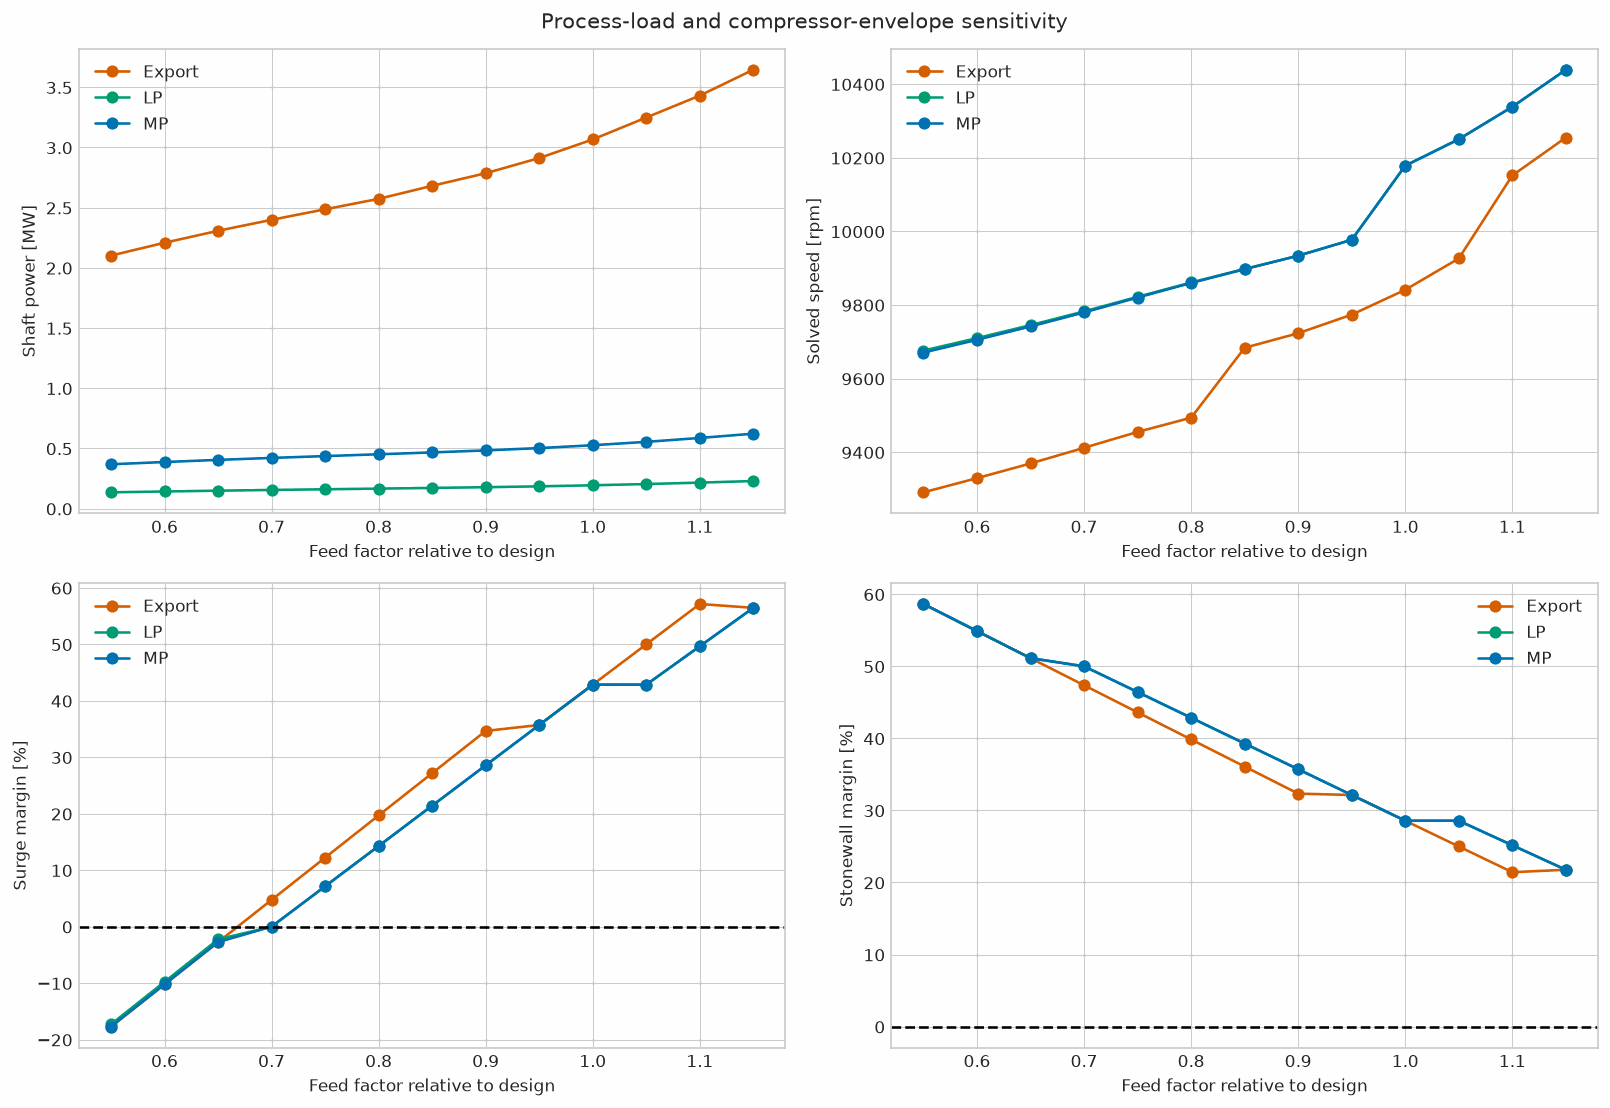

In [13]:
figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))
for machine_name, machine_data in machine_sweep.groupby("Machine"):
    color = COLORS[machine_name.lower()]
    axes[0, 0].plot(
        machine_data["Feed factor"],
        machine_data["Power [MW]"],
        marker="o",
        label=machine_name,
        color=color,
    )
    axes[0, 1].plot(
        machine_data["Feed factor"],
        machine_data["Speed [rpm]"],
        marker="o",
        label=machine_name,
        color=color,
    )
    axes[1, 0].plot(
        machine_data["Feed factor"],
        machine_data["Surge margin [%]"],
        marker="o",
        label=machine_name,
        color=color,
    )
    axes[1, 1].plot(
        machine_data["Feed factor"],
        machine_data["Stonewall margin [%]"],
        marker="o",
        label=machine_name,
        color=color,
    )

axes[1, 0].axhline(0.0, color="black", linestyle="--")
axes[1, 1].axhline(0.0, color="black", linestyle="--")
axes[0, 0].set_ylabel("Shaft power [MW]")
axes[0, 1].set_ylabel("Solved speed [rpm]")
axes[1, 0].set_ylabel("Surge margin [%]")
axes[1, 1].set_ylabel("Stonewall margin [%]")
for axis in axes.flat:
    axis.set_xlabel("Feed factor relative to design")
    axis.legend()

figure.suptitle("Process-load and compressor-envelope sensitivity")
figure.tight_layout()
plt.show()

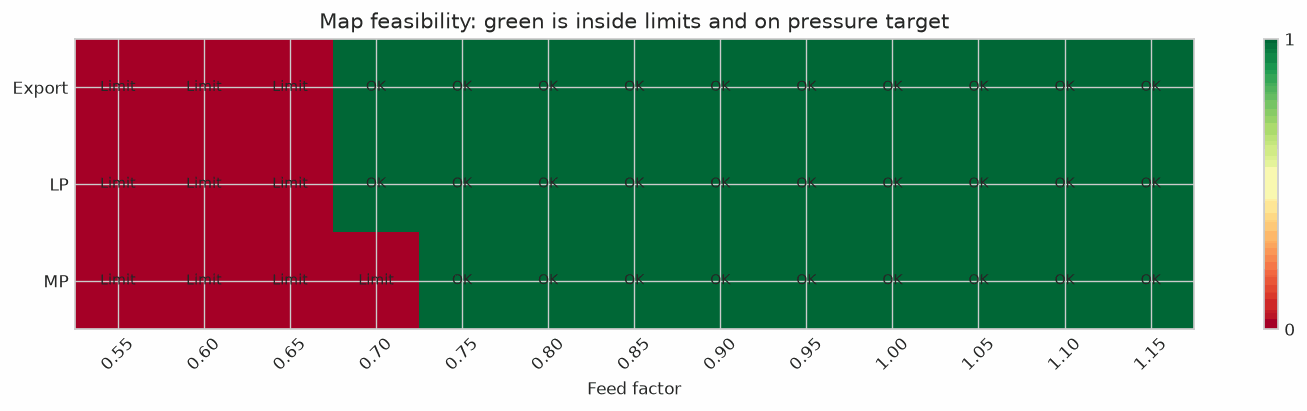

In [14]:
envelope_matrix = machine_sweep.pivot(
    index="Machine",
    columns="Feed factor",
    values="Map feasible",
).astype(int)

figure, axis = plt.subplots(figsize=(12.0, 3.4))
image = axis.imshow(
    envelope_matrix,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
)
axis.set_yticks(np.arange(len(envelope_matrix.index)))
axis.set_yticklabels(envelope_matrix.index)
axis.set_xticks(np.arange(len(envelope_matrix.columns)))
axis.set_xticklabels(
    [f"{value:.2f}" for value in envelope_matrix.columns],
    rotation=45,
)
axis.set(
    xlabel="Feed factor",
    title="Map feasibility: green is inside limits and on pressure target",
)
for row_index in range(envelope_matrix.shape[0]):
    for column_index in range(envelope_matrix.shape[1]):
        label = "OK" if envelope_matrix.iloc[row_index, column_index] else "Limit"
        axis.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=8,
        )
figure.colorbar(image, ax=axis, ticks=[0, 1])
figure.tight_layout()
plt.show()

## 10. Direct transfer of NeqSim compressor maps to eCalc

eCalc supports user-defined `VARIABLE_SPEED` compressor charts. The transfer is lossless for the
map arrays:

- NeqSim actual suction flow in m³/h → eCalc `AM3_PER_HOUR`;
- NeqSim polytropic head in kJ/kg → eCalc `KJ_PER_KG`;
- NeqSim efficiency in percent → eCalc `PERCENTAGE`; and
- each NeqSim speed line → one eCalc `CURVES` entry.

eCalc interprets the lowest-rate points as the surge line and the highest-rate points as
stonewall. A 10% control margin moves the operational control line to the right of surge.

In [15]:
ECALC_COMPONENT_MAP = {
    "water": "water",
    "nitrogen": "nitrogen",
    "CO2": "CO2",
    "methane": "methane",
    "ethane": "ethane",
    "propane": "propane",
    "i_butane": "i-butane",
    "n_butane": "n-butane",
    "i_pentane": "i-pentane",
    "n_pentane": "n-pentane",
    "n_hexane": "n-hexane",
}


def ecalc_fluid_composition(stream):
    phase = stream.getFluid().getPhase(0)
    composition = {}
    retained_fraction = 0.0
    for ecalc_name, neqsim_name in ECALC_COMPONENT_MAP.items():
        value = float(phase.getComponent(neqsim_name).getx())
        composition[ecalc_name] = value
        retained_fraction += value
    normalized = {
        name: 100.0 * value / retained_fraction
        for name, value in composition.items()
    }
    return normalized, retained_fraction


def ecalc_chart_model(machine_name, chart):
    curves = []
    for speed, flows, heads, efficiencies in zip(
        chart.getSpeeds(),
        chart.getFlows(),
        chart.getHeads(),
        chart.getPolytropicEfficiencies(),
    ):
        curves.append(
            {
                "SPEED": float(speed),
                "RATE": [float(value) for value in flows],
                "HEAD": [float(value) for value in heads],
                "EFFICIENCY": [
                    float(value) for value in efficiencies
                ],
            }
        )
    return {
        "NAME": f"{machine_name.lower()}_chart",
        "TYPE": "COMPRESSOR_CHART",
        "CHART_TYPE": "VARIABLE_SPEED",
        "UNITS": {
            "RATE": "AM3_PER_HOUR",
            "HEAD": "KJ_PER_KG",
            "EFFICIENCY": "PERCENTAGE",
        },
        "CURVES": curves,
    }


ecalc_fluid_models = []
ecalc_chart_models = []
ecalc_train_models = []
fluid_transfer_rows = []
for machine_name, compressor in compressors.items():
    composition, retained_fraction = ecalc_fluid_composition(
        compressor.getInletStream()
    )
    fluid_transfer_rows.append(
        {
            "Machine": machine_name,
            "Fraction retained through n-hexane": retained_fraction,
            "Fraction omitted as C7+": 1.0 - retained_fraction,
        }
    )
    ecalc_fluid_models.append(
        {
            "NAME": f"{machine_name.lower()}_fluid",
            "TYPE": "FLUID",
            "FLUID_MODEL_TYPE": "COMPOSITION",
            "EOS_MODEL": "SRK",
            "COMPOSITION": composition,
        }
    )
    ecalc_chart_models.append(
        ecalc_chart_model(
            machine_name,
            compressor_charts[machine_name],
        )
    )
    ecalc_train_models.append(
        {
            "NAME": f"{machine_name.lower()}_train",
            "TYPE": "VARIABLE_SPEED_COMPRESSOR_TRAIN",
            "FLUID_MODEL": f"{machine_name.lower()}_fluid",
            "PRESSURE_CONTROL": "DOWNSTREAM_CHOKE",
            "COMPRESSOR_TRAIN": {
                "STAGES": [
                    {
                        "INLET_TEMPERATURE": (
                            float(
                                compressor.getInletStream().getTemperature(
                                    "C"
                                )
                            )
                        ),
                        "COMPRESSOR_CHART": (
                            f"{machine_name.lower()}_chart"
                        ),
                        "CONTROL_MARGIN": 10.0,
                        "CONTROL_MARGIN_UNIT": "PERCENTAGE",
                    }
                ]
            },
        }
    )

fluid_transfer_table = pd.DataFrame(fluid_transfer_rows)
display(fluid_transfer_table)

,Machine,Fraction retained through n-hexane,Fraction omitted as C7+
0,LP,0.992346,0.007654
1,MP,0.997295,0.002705
2,Export,0.995554,0.004446


## 11. Generate an eCalc generator-set curve with NeqSim

The eCalc `ELECTRICITY2FUEL` table is generated from NeqSim's `GasTurbineUnit`, not invented as a
linear efficiency. The TITAN 250 performance map supplies load-dependent heat rate, thermal
efficiency, fuel demand, and direct CO₂.

The fuel conversion uses a NeqSim standard-density calculation:

$$
\dot V_{\mathrm{fuel,std}} =
\frac{\dot m_{\mathrm{fuel}}}{\rho_{\mathrm{fuel,std}}}
$$

The eCalc CO₂ factor is derived consistently from the native turbine results:

$$
f_{\mathrm{CO_2}} =
\frac{\dot m_{\mathrm{CO_2}}}
{\dot V_{\mathrm{fuel,std}}}
$$

In [16]:
GasTurbineCatalog = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineCatalog
)
GasTurbineUnit = (
    jneqsim.process.equipment.powergeneration.gasturbine.GasTurbineUnit
)


def make_fuel_fluid(temperature_c, pressure_bara, flow_kg_h):
    composition, _ = ecalc_fluid_composition(
        compressors["Export"].getInletStream()
    )
    reverse_names = {
        ecalc_name: neqsim_name
        for ecalc_name, neqsim_name in ECALC_COMPONENT_MAP.items()
    }
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for ecalc_name, mole_percent in composition.items():
        fluid.addComponent(
            reverse_names[ecalc_name],
            mole_percent,
        )
    fluid.setMixingRule("classic")
    fluid.setTotalFlowRate(flow_kg_h, "kg/hr")
    return fluid


standard_fuel_stream = Stream(
    "standard fuel density",
    make_fuel_fluid(15.0, 1.01325, 1_000.0),
)
standard_fuel_stream.run()
fuel_standard_density_kg_m3 = standard_fuel_stream.getFluid().getDensity(
    "kg/m3"
)

turbine_specification = GasTurbineCatalog.get("TITAN_250")
turbine_demands_mw = np.concatenate(
    ([0.0], np.linspace(0.5, 22.0, 18))
)
turbine_rows = []
for demand_mw in turbine_demands_mw:
    if demand_mw == 0.0:
        turbine_rows.append(
            {
                "Power [MW]": 0.0,
                "Fuel [Sm³/d]": 0.0,
                "Fuel [kg/h]": 0.0,
                "CO₂ [kg/h]": 0.0,
                "Efficiency [%]": np.nan,
                "Heat rate [kJ/kWh]": np.nan,
                "CO₂ intensity [kg/MWh]": np.nan,
            }
        )
        continue
    fuel_stream = Stream(
        f"TITAN 250 fuel at {demand_mw:.2f} MW",
        make_fuel_fluid(15.0, 25.0, 1_000.0),
    )
    turbine = GasTurbineUnit(
        f"TITAN 250 at {demand_mw:.2f} MW",
        fuel_stream,
        turbine_specification,
    )
    turbine.setAmbientTemperatureK(15.0 + 273.15)
    turbine.setAmbientPressureBara(1.01325)
    turbine.setDemandedPower(demand_mw * 1.0e6)
    turbine.run()
    fuel_kg_h = turbine.getFuelMassFlowKgPerHr()
    fuel_sm3_d = (
        fuel_kg_h / fuel_standard_density_kg_m3 * 24.0
    )
    turbine_rows.append(
        {
            "Power [MW]": demand_mw,
            "Fuel [Sm³/d]": fuel_sm3_d,
            "Fuel [kg/h]": fuel_kg_h,
            "CO₂ [kg/h]": turbine.getCO2EmissionKgPerHr(),
            "Efficiency [%]": (
                100.0 * turbine.getThermalEfficiency()
            ),
            "Heat rate [kJ/kWh]": (
                turbine.getEffectiveHeatRateKJPerKWh()
            ),
            "CO₂ intensity [kg/MWh]": (
                turbine.getCO2IntensityKgPerMWh()
            ),
        }
    )

turbine_curve = pd.DataFrame(turbine_rows)
positive_turbine = turbine_curve["Fuel [Sm³/d]"] > 0.0
co2_factors = (
    turbine_curve.loc[positive_turbine, "CO₂ [kg/h]"]
    / (
        turbine_curve.loc[positive_turbine, "Fuel [Sm³/d]"]
        / 24.0
    )
)
ecalc_co2_factor_kg_sm3 = float(co2_factors.median())
display(turbine_curve.round(4))
print(
    "Fuel standard density:",
    f"{fuel_standard_density_kg_m3:.6f} kg/Sm³",
)
print(
    "Transferred eCalc CO₂ factor:",
    f"{ecalc_co2_factor_kg_sm3:.6f} kg/Sm³",
)

Fuel standard density: 0.964689 kg/Sm³
Transferred eCalc CO₂ factor: 2.616750 kg/Sm³


,Power [MW],Fuel [Sm³/d],Fuel [kg/h],CO₂ [kg/h],Efficiency [%],Heat rate [kJ/kWh],CO₂ intensity [kg/MWh]
0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN
1,0.5000,3750.9544,150.7710,408.9713,26.3764,13648.5784,817.9426
2,1.7647,13238.6625,532.1328,1443.4282,26.3764,13648.5784,817.9426
3,3.0294,22726.3707,913.4946,2477.8850,26.3764,13648.5784,817.9426
4,4.2941,32214.0788,1294.8564,3512.3419,26.3764,13648.5784,817.9426
5,5.5588,39717.5842,1596.4625,4330.4586,27.6941,12999.1686,779.0243
6,6.8235,46133.6914,1854.3602,5030.0149,29.2670,12300.5570,737.1574
7,8.0882,51879.3447,2085.3088,5656.4708,30.8494,11669.6101,699.3455
8,9.3529,57095.6536,2294.9802,6225.2116,32.4140,11106.3278,665.5887
9,10.6176,61923.7280,2489.0464,6751.6226,33.9280,10610.7101,635.8869


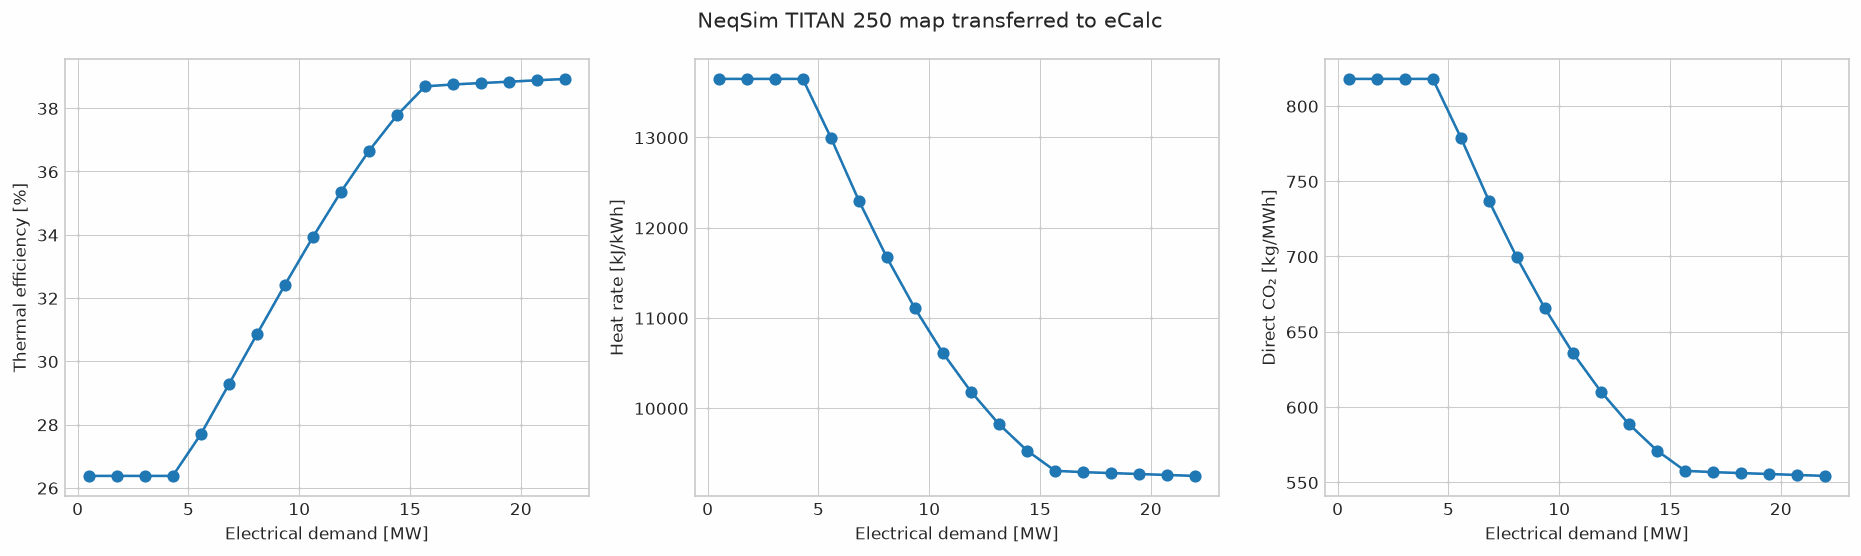

In [17]:
figure, axes = plt.subplots(1, 3, figsize=(15.0, 4.5))
positive_curve = turbine_curve[positive_turbine]
axes[0].plot(
    positive_curve["Power [MW]"],
    positive_curve["Efficiency [%]"],
    marker="o",
)
axes[1].plot(
    positive_curve["Power [MW]"],
    positive_curve["Heat rate [kJ/kWh]"],
    marker="o",
)
axes[2].plot(
    positive_curve["Power [MW]"],
    positive_curve["CO₂ intensity [kg/MWh]"],
    marker="o",
)
axes[0].set_ylabel("Thermal efficiency [%]")
axes[1].set_ylabel("Heat rate [kJ/kWh]")
axes[2].set_ylabel("Direct CO₂ [kg/MWh]")
for axis in axes:
    axis.set_xlabel("Electrical demand [MW]")
figure.suptitle("NeqSim TITAN 250 map transferred to eCalc")
figure.tight_layout()
plt.show()

## 12. Field-life depletion and inlet-pressure strategy

The field-life calculation compares two surface-pressure strategies while reservoir pressure
declines from 220 to 120 bara:

- **fixed pressure:** the high-pressure separator remains at 70 bara; and
- **pressure reduction:** the inlet pressure is lowered in steps from 70 to 25 bara.

The synthetic well deliverability follows a calibrated back-pressure relation:

$$
\dot m =
C\left(p_{\mathrm{res}}^2-p_{\mathrm{inlet}}^2\right)^n
$$

with $n=0.8$. Lower inlet pressure increases production relative to the fixed-pressure reference,
but it also raises export-compressor head and power. The MP and LP separator pressures are reduced
proportionally. Every annual point is re-simulated in NeqSim with the complete compressor maps;
surge, stonewall, speed, and discharge-pressure constraints are retained rather than hidden.

This is a screening deliverability model, not a reservoir simulation. Its value is to expose the
coupled trade-off between incremental recovery and surface compression.

In [18]:
FIELD_YEARS = np.arange(2027, 2038)
RESERVOIR_PRESSURE_BARA = np.linspace(220.0, 120.0, len(FIELD_YEARS))
REDUCED_HP_PRESSURE_BARA = np.array(
    [70.0, 70.0, 65.0, 60.0, 55.0, 50.0, 45.0, 40.0, 35.0, 30.0, 25.0]
)
FIXED_HP_PRESSURE_BARA = np.full(len(FIELD_YEARS), HP_PRESSURE_BARA)
DELIVERABILITY_EXPONENT = 0.8
DELIVERABILITY_COEFFICIENT = BASE_FEED_KG_H / (
    (
        RESERVOIR_PRESSURE_BARA[0] ** 2
        - HP_PRESSURE_BARA**2
    )
    ** DELIVERABILITY_EXPONENT
)


def well_deliverability_kg_h(
    reservoir_pressure_bara,
    inlet_pressure_bara,
):
    pseudo_pressure_drawdown = max(
        reservoir_pressure_bara**2 - inlet_pressure_bara**2,
        0.0,
    )
    return DELIVERABILITY_COEFFICIENT * (
        pseudo_pressure_drawdown**DELIVERABILITY_EXPONENT
    )


def staged_separator_pressures(hp_pressure_bara):
    mp_pressure_bara = max(
        8.5,
        hp_pressure_bara * MP_PRESSURE_BARA / HP_PRESSURE_BARA,
    )
    lp_pressure_bara = max(
        4.5,
        hp_pressure_bara * LP_PRESSURE_BARA / HP_PRESSURE_BARA,
    )
    return mp_pressure_bara, lp_pressure_bara

In [19]:
def evaluate_field_life_point(
    strategy_name,
    year,
    reservoir_pressure_bara,
    hp_pressure_bara,
):
    flow_kg_h = well_deliverability_kg_h(
        reservoir_pressure_bara,
        hp_pressure_bara,
    )
    mp_pressure_bara, lp_pressure_bara = staged_separator_pressures(
        hp_pressure_bara
    )
    case = run_process_case(
        build_process_case(
            flow_kg_h=flow_kg_h,
            hp_pressure_bara=hp_pressure_bara,
            mp_pressure_bara=mp_pressure_bara,
            lp_pressure_bara=lp_pressure_bara,
        )
    )
    case_compressors = {
        "LP": case["lp_compressor"],
        "MP": case["mp_compressor"],
        "Export": case["export_compressor"],
    }
    pressure_targets = {
        "LP": mp_pressure_bara,
        "MP": hp_pressure_bara,
        "Export": EXPORT_PRESSURE_BARA,
    }
    for machine_name, compressor in case_compressors.items():
        compressor.setCompressorChart(compressor_charts[machine_name])
        compressor.setOutletPressure(
            pressure_targets[machine_name],
            "bara",
        )
        compressor.setSolveSpeed(True)
        compressor.setMinimumSpeed(7_500.0)
        compressor.setMaximumSpeed(10_500.0)
        compressor.setLimitSpeed(True)
    run_process_case(case)

    row = {
        "Strategy": strategy_name,
        "Year": int(year),
        "Reservoir pressure [bara]": reservoir_pressure_bara,
        "HP pressure [bara]": hp_pressure_bara,
        "MP pressure [bara]": mp_pressure_bara,
        "LP pressure [bara]": lp_pressure_bara,
        "Feed [kg/h]": flow_kg_h,
    }
    feasible_flags = []
    pressure_flags = []
    compressor_power_mw = 0.0
    for machine_name, compressor in case_compressors.items():
        chart = compressor_charts[machine_name]
        speed_rpm = compressor.getSpeed()
        actual_flow_m3_h = compressor.getInletStream().getFlowRate(
            "m3/hr"
        )
        surge_flow_m3_h = chart.getSurgeFlowAtSpeed(speed_rpm)
        stonewall_flow_m3_h = chart.getStoneWallFlowAtSpeed(speed_rpm)
        surge_margin = 100.0 * (
            actual_flow_m3_h - surge_flow_m3_h
        ) / surge_flow_m3_h
        stonewall_margin = 100.0 * (
            stonewall_flow_m3_h - actual_flow_m3_h
        ) / stonewall_flow_m3_h
        discharge_pressure_bara = compressor.getOutletStream().getPressure(
            "bara"
        )
        pressure_error_bara = (
            discharge_pressure_bara - pressure_targets[machine_name]
        )
        map_feasible = surge_margin > 0.0 and stonewall_margin > 0.0
        pressure_met = abs(pressure_error_bara) < 0.5
        feasible_flags.append(map_feasible)
        pressure_flags.append(pressure_met)
        compressor_power_mw += compressor.getPower("MW")
        prefix = machine_name.upper()
        row[f"{prefix}_RATE"] = compressor.getInletStream().getFlowRate(
            "Sm3/day"
        )
        row[f"{prefix} speed [rpm]"] = speed_rpm
        row[f"{prefix} head [kJ/kg]"] = compressor.getPolytropicHead(
            "kJ/kg"
        )
        row[f"{prefix} surge margin [%]"] = surge_margin
        row[f"{prefix} stonewall margin [%]"] = stonewall_margin
        row[f"{prefix} pressure error [bar]"] = pressure_error_bara

    export_gas = case["export_aftercooler"].getOutletStream()
    stable_liquid = case["lp_separator"].getLiquidOutStream()
    row["Export gas [Sm³/d]"] = export_gas.getFlowRate("Sm3/day")
    row["Stable liquid [kg/h]"] = stable_liquid.getFlowRate("kg/hr")
    row["Compressor power [MW]"] = compressor_power_mw
    row["Total load [MW]"] = (
        compressor_power_mw + FIXED_UTILITY_LOAD_MW
    )
    row["All maps feasible"] = all(feasible_flags)
    row["All pressure targets met"] = all(pressure_flags)
    row["Minimum surge margin [%]"] = min(
        row[f"{name} surge margin [%]"] for name in ["LP", "MP", "EXPORT"]
    )
    row["Minimum stonewall margin [%]"] = min(
        row[f"{name} stonewall margin [%]"]
        for name in ["LP", "MP", "EXPORT"]
    )
    return row


field_life_rows = []
pressure_strategies = {
    "Fixed 70 bara": FIXED_HP_PRESSURE_BARA,
    "Reduced inlet pressure": REDUCED_HP_PRESSURE_BARA,
}
for strategy_name, pressure_schedule in pressure_strategies.items():
    for year, reservoir_pressure, inlet_pressure in zip(
        FIELD_YEARS,
        RESERVOIR_PRESSURE_BARA,
        pressure_schedule,
    ):
        field_life_rows.append(
            evaluate_field_life_point(
                strategy_name,
                year,
                reservoir_pressure,
                inlet_pressure,
            )
        )

field_life_results = pd.DataFrame(field_life_rows)
display(
    field_life_results[
        [
            "Strategy",
            "Year",
            "Reservoir pressure [bara]",
            "HP pressure [bara]",
            "Feed [kg/h]",
            "Total load [MW]",
            "Minimum surge margin [%]",
            "Minimum stonewall margin [%]",
            "All pressure targets met",
        ]
    ].round(3)
)

,Strategy,Year,Reservoir pressure [bara],HP pressure [bara],Feed [kg/h],Total load [MW],Minimum surge margin [%],Minimum stonewall margin [%],All pressure targets met
0,Fixed 70 bara,2027,220.0,70.0,180000.000,11.787,42.857,28.571,True
1,Fixed 70 bara,2028,210.0,70.0,165618.922,11.507,31.444,30.819,True
2,Fixed 70 bara,2029,200.0,70.0,151609.632,11.305,20.325,36.671,True
3,Fixed 70 bara,2030,190.0,70.0,137976.389,11.134,9.505,42.366,True
4,Fixed 70 bara,2031,180.0,70.0,124723.203,10.973,-1.013,47.902,True
5,Fixed 70 bara,2032,170.0,70.0,111853.633,10.803,-7.020,53.278,True
6,Fixed 70 bara,2033,160.0,70.0,99370.477,10.611,-17.397,58.492,True
7,Fixed 70 bara,2034,150.0,70.0,87275.277,10.419,-27.451,61.519,True
8,Fixed 70 bara,2035,140.0,70.0,75567.485,10.906,-42.882,68.435,False
9,Fixed 70 bara,2036,130.0,70.0,64243.042,10.626,-51.441,73.165,False


### Incremental production and compression consequence

The annualized difference is integrated using 8,760 hours per year. It is an incremental
wellstream mass result for the synthetic fluid. A real development study would integrate
component-level gas, oil, water, and reservoir offtake with a reservoir simulator.

In [20]:
fixed_life = field_life_results[
    field_life_results["Strategy"] == "Fixed 70 bara"
].reset_index(drop=True)
reduced_life = field_life_results[
    field_life_results["Strategy"] == "Reduced inlet pressure"
].reset_index(drop=True)

field_life_comparison = pd.DataFrame(
    {
        "Year": FIELD_YEARS,
        "Reservoir pressure [bara]": RESERVOIR_PRESSURE_BARA,
        "Reduced inlet pressure [bara]": REDUCED_HP_PRESSURE_BARA,
        "Fixed-pressure feed [kg/h]": fixed_life["Feed [kg/h]"],
        "Reduced-pressure feed [kg/h]": reduced_life["Feed [kg/h]"],
        "Production uplift [%]": 100.0
        * (
            reduced_life["Feed [kg/h]"]
            / fixed_life["Feed [kg/h]"]
            - 1.0
        ),
        "Incremental feed [Mt/y]": (
            (
                reduced_life["Feed [kg/h]"]
                - fixed_life["Feed [kg/h]"]
            )
            * 8760.0
            / 1.0e9
        ),
        "Fixed-pressure load [MW]": fixed_life["Total load [MW]"],
        "Reduced-pressure load [MW]": reduced_life["Total load [MW]"],
        "Reduced-pressure map feasible": reduced_life[
            "All maps feasible"
        ],
        "Reduced-pressure targets met": reduced_life[
            "All pressure targets met"
        ],
    }
)
field_life_comparison["Cumulative incremental feed [Mt]"] = (
    field_life_comparison["Incremental feed [Mt/y]"].cumsum()
)
display(field_life_comparison.round(4))

,Year,Reservoir pressure [bara],Reduced inlet pressure [bara],Fixed-pressure feed [kg/h],Reduced-pressure feed [kg/h],Production uplift [%],Incremental feed [Mt/y],Fixed-pressure load [MW],Reduced-pressure load [MW],Reduced-pressure map feasible,Reduced-pressure targets met,Cumulative incremental feed [Mt]
0,2027,220.0,70.0,180000.0000,180000.0000,0.0000,0.0000,11.7869,11.7869,True,True,0.0000
1,2028,210.0,70.0,165618.9219,165618.9219,0.0000,0.0000,11.5069,11.5069,True,True,0.0000
2,2029,200.0,65.0,151609.6317,153937.6362,1.5355,0.0204,11.3054,11.5464,True,True,0.0204
3,2030,190.0,60.0,137976.3890,142556.7508,3.3197,0.0401,11.1337,11.5079,True,False,0.0605
4,2031,180.0,55.0,124723.2028,131481.1215,5.4183,0.0592,10.9735,11.1996,True,False,0.1197
5,2032,170.0,50.0,111853.6326,120715.8345,7.9230,0.0776,10.8033,10.9021,False,False,0.1973
6,2033,160.0,45.0,99370.4773,110266.2133,10.9648,0.0954,10.6111,10.6185,False,False,0.2928
7,2034,150.0,40.0,87275.2766,100137.8190,14.7379,0.1127,10.4191,10.4543,False,False,0.4055
8,2035,140.0,35.0,75567.4848,90336.4412,19.5441,0.1294,10.9059,10.2053,False,False,0.5348
9,2036,130.0,30.0,64243.0419,80868.0714,25.8783,0.1456,10.6259,9.8689,False,False,0.6805


### Constraint diagnosis and intervention timing

A positive production uplift is not sufficient to approve pressure reduction. The table below
identifies which compressor first loses discharge-pressure capability or crosses a map boundary.
A failed discharge target at maximum speed indicates that more head is required than the generated
map can deliver; typical responses are a lower-pressure retrofit, another casing/stage, parallel
capacity, or a revised pressure schedule.

In [21]:
constraint_rows = []
for _, annual_result in reduced_life.iterrows():
    for machine_name in ["LP", "MP", "EXPORT"]:
        pressure_error = annual_result[
            f"{machine_name} pressure error [bar]"
        ]
        surge_margin = annual_result[
            f"{machine_name} surge margin [%]"
        ]
        stonewall_margin = annual_result[
            f"{machine_name} stonewall margin [%]"
        ]
        if abs(pressure_error) >= 0.5:
            status = "Discharge target not met"
        elif surge_margin <= 0.0:
            status = "At or below surge"
        elif stonewall_margin <= 0.0:
            status = "At or beyond stonewall"
        else:
            status = "Inside map and target met"
        constraint_rows.append(
            {
                "Year": int(annual_result["Year"]),
                "Machine": machine_name.title(),
                "HP inlet [bara]": annual_result["HP pressure [bara]"],
                "Speed [rpm]": annual_result[
                    f"{machine_name} speed [rpm]"
                ],
                "Head [kJ/kg]": annual_result[
                    f"{machine_name} head [kJ/kg]"
                ],
                "Surge margin [%]": surge_margin,
                "Stonewall margin [%]": stonewall_margin,
                "Pressure error [bar]": pressure_error,
                "Status": status,
            }
        )

constraint_diagnostics = pd.DataFrame(constraint_rows)
constraint_events = constraint_diagnostics[
    constraint_diagnostics["Status"] != "Inside map and target met"
]
display(constraint_events.round(3))


def first_failure_year(results, column_name):
    failures = results.loc[~results[column_name], "Year"]
    return "None" if failures.empty else int(failures.iloc[0])


field_life_decision_summary = pd.Series(
    {
        "Cumulative incremental feed [Mt]": field_life_comparison[
            "Cumulative incremental feed [Mt]"
        ].iloc[-1],
        "End-of-study production uplift [%]": field_life_comparison[
            "Production uplift [%]"
        ].iloc[-1],
        "First reduced-pressure map-envelope failure": (
            first_failure_year(reduced_life, "All maps feasible")
        ),
        "First reduced-pressure discharge-target failure": (
            first_failure_year(
                reduced_life,
                "All pressure targets met",
            )
        ),
        "End export pressure ratio": (
            EXPORT_PRESSURE_BARA
            / REDUCED_HP_PRESSURE_BARA[-1]
        ),
        "Late-life compression decision": (
            "Retrofit or re-stage before further pressure reduction"
        ),
    },
    name="Field-life decision result",
)
display(field_life_decision_summary.to_frame())

,Year,Machine,HP inlet [bara],Speed [rpm],Head [kJ/kg],Surge margin [%],Stonewall margin [%],Pressure error [bar],Status
11,2030,Export,60.0,10500.000,108.174,29.685,35.157,-2.522,Discharge target not met
14,2031,Export,55.0,10500.000,107.528,32.641,33.680,-17.423,Discharge target not met
16,2032,Mp,50.0,9283.595,89.584,-3.729,51.624,0.000,At or below surge
17,2032,Export,50.0,10500.000,106.647,36.265,31.867,-32.111,Discharge target not met
19,2033,Mp,45.0,9139.138,86.940,-8.421,53.753,0.000,At or below surge
20,2033,Export,45.0,10500.000,105.339,40.793,29.603,-46.721,Discharge target not met
22,2034,Mp,40.0,10500.000,123.909,-28.549,64.275,20.815,Discharge target not met
23,2034,Export,40.0,10500.000,103.204,46.579,26.711,-61.481,Discharge target not met
24,2035,Lp,35.0,10500.000,124.751,-33.213,66.606,10.071,Discharge target not met
25,2035,Mp,35.0,10500.000,126.233,-37.928,68.964,19.158,Discharge target not met


,Field-life decision result
Cumulative incremental feed [Mt],0.84208
End-of-study production uplift [%],34.615293
First reduced-pressure map-envelope failure,2032
First reduced-pressure discharge-target failure,2030
End export pressure ratio,6.4
Late-life compression decision,Retrofit or re-stage before further pressure r...


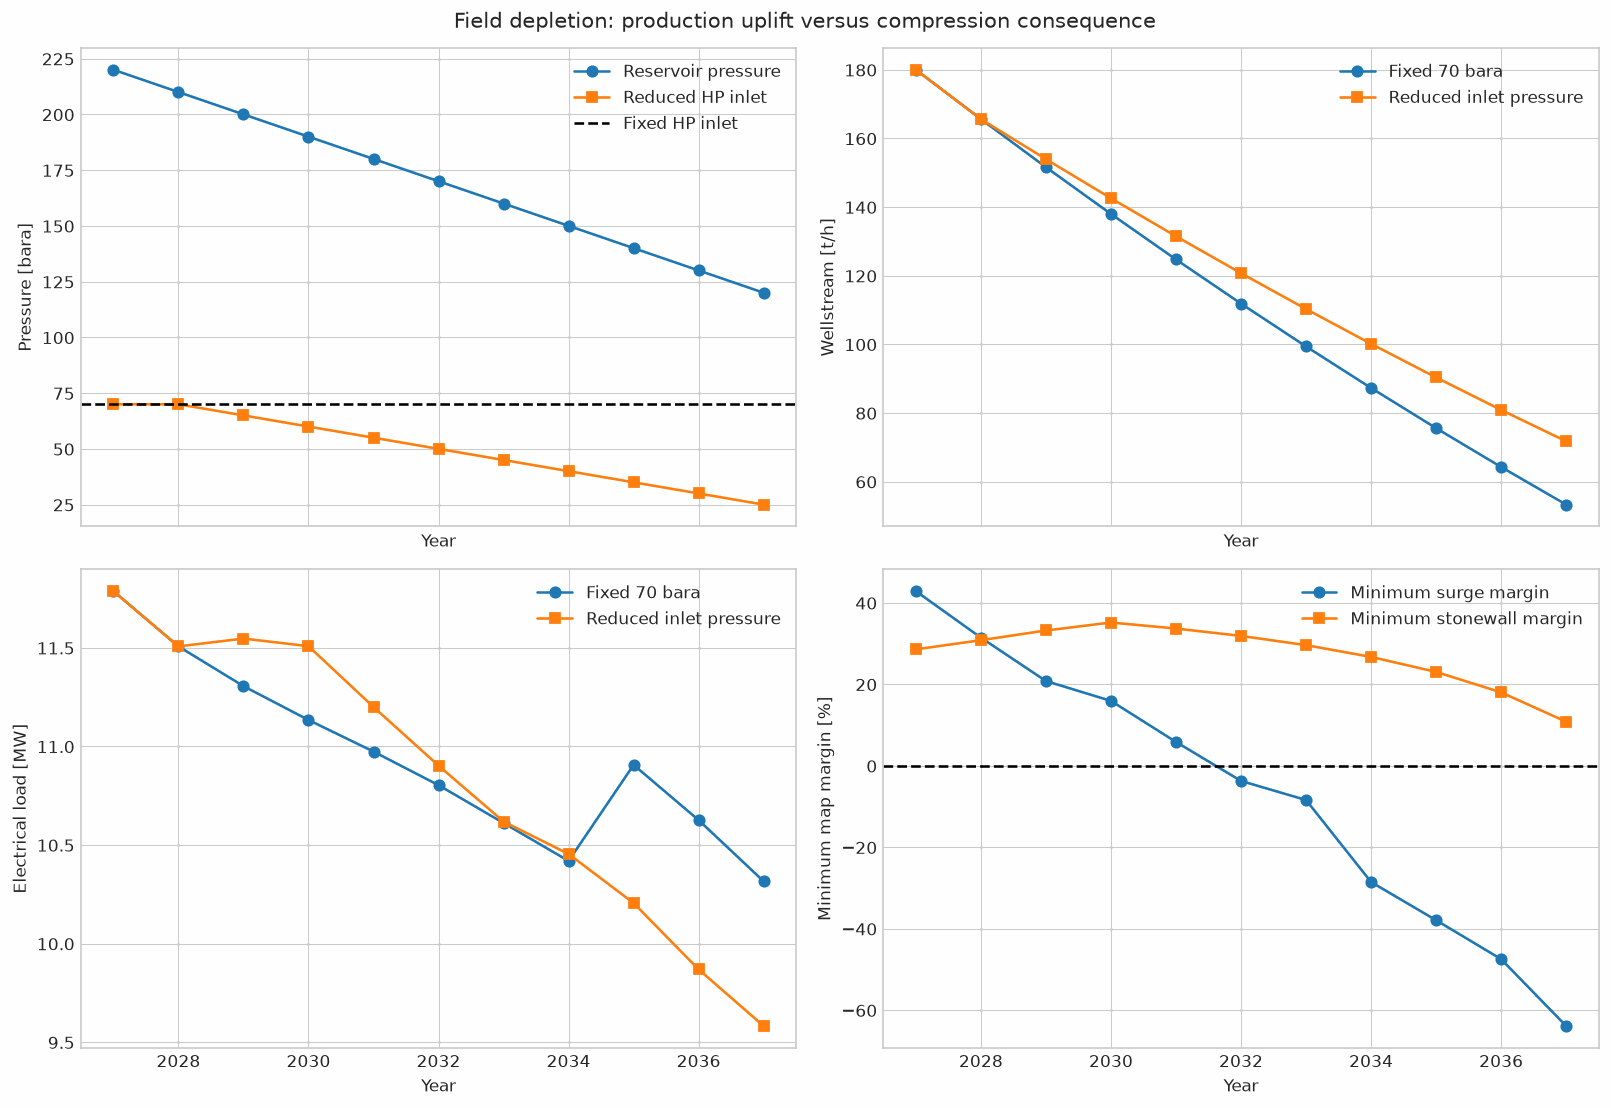

In [22]:
figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0), sharex=True)
axes[0, 0].plot(
    FIELD_YEARS,
    RESERVOIR_PRESSURE_BARA,
    marker="o",
    label="Reservoir pressure",
)
axes[0, 0].plot(
    FIELD_YEARS,
    REDUCED_HP_PRESSURE_BARA,
    marker="s",
    label="Reduced HP inlet",
)
axes[0, 0].axhline(
    HP_PRESSURE_BARA,
    linestyle="--",
    color="black",
    label="Fixed HP inlet",
)
axes[0, 0].set_ylabel("Pressure [bara]")
axes[0, 0].legend()

axes[0, 1].plot(
    FIELD_YEARS,
    fixed_life["Feed [kg/h]"] / 1000.0,
    marker="o",
    label="Fixed 70 bara",
)
axes[0, 1].plot(
    FIELD_YEARS,
    reduced_life["Feed [kg/h]"] / 1000.0,
    marker="s",
    label="Reduced inlet pressure",
)
axes[0, 1].set_ylabel("Wellstream [t/h]")
axes[0, 1].legend()

axes[1, 0].plot(
    FIELD_YEARS,
    fixed_life["Total load [MW]"],
    marker="o",
    label="Fixed 70 bara",
)
axes[1, 0].plot(
    FIELD_YEARS,
    reduced_life["Total load [MW]"],
    marker="s",
    label="Reduced inlet pressure",
)
axes[1, 0].set_ylabel("Electrical load [MW]")
axes[1, 0].legend()

axes[1, 1].plot(
    FIELD_YEARS,
    reduced_life["Minimum surge margin [%]"],
    marker="o",
    label="Minimum surge margin",
)
axes[1, 1].plot(
    FIELD_YEARS,
    reduced_life["Minimum stonewall margin [%]"],
    marker="s",
    label="Minimum stonewall margin",
)
axes[1, 1].axhline(0.0, color="black", linestyle="--")
axes[1, 1].set_ylabel("Minimum map margin [%]")
axes[1, 1].legend()

for axis in axes.flat:
    axis.set_xlabel("Year")
figure.suptitle(
    "Field depletion: production uplift versus compression consequence"
)
figure.tight_layout()
plt.show()

### eCalc field-life profile

Every compressor rate and each suction/discharge pressure below comes from the annual NeqSim
pressure-reduction cases. Hydrocarbon export is an educational oil-equivalent proxy:

$$
\dot V_{\mathrm{HC,eq}} =
\frac{\dot V_{\mathrm{gas,std}}}{1000}
+
\frac{\dot m_{\mathrm{stable\ liquid}}}{800\ \mathrm{kg/m^3}}
$$

The assumed liquid density is used only for the intensity denominator.

In [23]:
forecast_profile = pd.DataFrame(
    {
        "Dates": [
            f"{year}-01-01 00:00:00" for year in FIELD_YEARS
        ],
        "FEED_FACTOR": (
            reduced_life["Feed [kg/h]"] / BASE_FEED_KG_H
        ),
        "EXPORT_GAS_RATE": reduced_life["Export gas [Sm³/d]"],
        "STABLE_LIQUID_KG_H": reduced_life["Stable liquid [kg/h]"],
        "LP_RATE": reduced_life["LP_RATE"],
        "MP_RATE": reduced_life["MP_RATE"],
        "EXPORT_RATE": reduced_life["EXPORT_RATE"],
        "LP_SUCTION_PRESSURE": reduced_life["LP pressure [bara]"],
        "LP_DISCHARGE_PRESSURE": reduced_life["MP pressure [bara]"],
        "MP_SUCTION_PRESSURE": reduced_life["MP pressure [bara]"],
        "MP_DISCHARGE_PRESSURE": reduced_life["HP pressure [bara]"],
        "EXPORT_SUCTION_PRESSURE": reduced_life["HP pressure [bara]"],
        "EXPORT_DISCHARGE_PRESSURE": EXPORT_PRESSURE_BARA,
        "NEQSIM_TOTAL_LOAD_MW": reduced_life["Total load [MW]"],
    }
)
forecast_factors = forecast_profile["FEED_FACTOR"].to_numpy()

forecast_profile["HC_EXPORT_EQ_SM3D"] = (
    forecast_profile["EXPORT_GAS_RATE"] / 1000.0
    + forecast_profile["STABLE_LIQUID_KG_H"] * 24.0 / 800.0
)
display(forecast_profile.round(3))

,Dates,FEED_FACTOR,EXPORT_GAS_RATE,STABLE_LIQUID_KG_H,LP_RATE,MP_RATE,EXPORT_RATE,LP_SUCTION_PRESSURE,LP_DISCHARGE_PRESSURE,MP_SUCTION_PRESSURE,MP_DISCHARGE_PRESSURE,EXPORT_SUCTION_PRESSURE,EXPORT_DISCHARGE_PRESSURE,NEQSIM_TOTAL_LOAD_MW,HC_EXPORT_EQ_SM3D
0,2027-01-01 00:00:00,1.000,2365738.910,83250.619,93433.892,311677.064,2365738.910,8.000,25.000,25.000,70.0,70.0,160.0,11.787,4863.257
1,2028-01-01 00:00:00,0.920,2176728.487,76599.321,85969.003,286775.663,2176728.487,8.000,25.000,25.000,70.0,70.0,160.0,11.507,4474.708
2,2029-01-01 00:00:00,0.855,2030297.420,70676.747,75581.535,244500.509,2030297.420,7.429,23.214,23.214,65.0,65.0,160.0,11.546,4150.600
3,2030-01-01 00:00:00,0.792,1887612.442,64879.824,65976.455,206676.642,1887612.442,6.857,21.429,21.429,60.0,60.0,160.0,11.508,3834.007
4,2031-01-01 00:00:00,0.730,1748714.711,59214.130,57129.719,172988.036,1748714.711,6.286,19.643,19.643,55.0,55.0,160.0,11.200,3525.139
5,2032-01-01 00:00:00,0.671,1613651.654,53684.862,49016.506,143139.723,1613651.654,5.714,17.857,17.857,50.0,50.0,160.0,10.902,3224.198
6,2033-01-01 00:00:00,0.613,1482479.025,48296.619,41611.045,116855.054,1482479.025,5.143,16.071,16.071,45.0,45.0,160.0,10.619,2931.378
7,2034-01-01 00:00:00,0.556,1355264.319,43053.019,34886.383,93873.303,1355264.319,4.571,14.286,14.286,40.0,40.0,160.0,10.454,2646.855
8,2035-01-01 00:00:00,0.502,1228565.552,38260.090,25286.569,70420.047,1228565.552,4.500,12.500,12.500,35.0,35.0,160.0,10.205,2376.368
9,2036-01-01 00:00:00,0.449,1106377.272,33588.664,16659.609,50138.616,1106377.272,4.500,10.714,10.714,30.0,30.0,160.0,9.869,2114.037


## 13. Build the eCalc model

The YAML model uses the recommended eCalc interface. It contains:

- the production time series;
- the NeqSim-derived generator-set curve;
- three SRK fluid definitions;
- three complete variable-speed compressor charts;
- three chart-based compressor trains;
- fixed utilities; and
- one installation-level fuel and emissions account.

In [24]:
ARTIFACT_DIRECTORY = Path("neqsim_ecalc_artifacts")
if ARTIFACT_DIRECTORY.exists():
    shutil.rmtree(ARTIFACT_DIRECTORY)
ARTIFACT_DIRECTORY.mkdir(parents=True)

forecast_profile.to_csv(
    ARTIFACT_DIRECTORY / "production_profile.csv",
    index=False,
)
turbine_curve[["Power [MW]", "Fuel [Sm³/d]"]].rename(
    columns={
        "Power [MW]": "POWER",
        "Fuel [Sm³/d]": "FUEL",
    }
).to_csv(
    ARTIFACT_DIRECTORY / "neqsim_titan250_genset.csv",
    index=False,
)

consumer_definitions = [
    {
        "NAME": "Fixed utilities and hotel load",
        "CATEGORY": "BASE-LOAD",
        "ENERGY_USAGE_MODEL": {
            "TYPE": "DIRECT",
            "LOAD": FIXED_UTILITY_LOAD_MW,
        },
    }
]
for machine_name in ["LP", "MP", "Export"]:
    consumer_definitions.append(
        {
            "NAME": f"{machine_name} compressor",
            "CATEGORY": "COMPRESSOR",
            "ENERGY_USAGE_MODEL": {
                "TYPE": "COMPRESSOR",
                "ENERGYFUNCTION": f"{machine_name.lower()}_train",
                "RATE": f"SIM;{machine_name.upper()}_RATE",
                "SUCTION_PRESSURE": (
                    f"SIM;{machine_name.upper()}_SUCTION_PRESSURE"
                ),
                "DISCHARGE_PRESSURE": (
                    f"SIM;{machine_name.upper()}_DISCHARGE_PRESSURE"
                ),
            },
        }
    )

ecalc_process_model = {
    "START": "2027-01-01",
    "END": "2037-01-01",
    "TIME_SERIES": [
        {
            "NAME": "SIM",
            "FILE": "production_profile.csv",
            "TYPE": "DEFAULT",
        }
    ],
    "FACILITY_INPUTS": [
        {
            "NAME": "neqsim_titan250_genset",
            "FILE": "neqsim_titan250_genset.csv",
            "TYPE": "ELECTRICITY2FUEL",
        }
    ],
    "MODELS": [
        *ecalc_fluid_models,
        *ecalc_chart_models,
        *ecalc_train_models,
    ],
    "FUEL_TYPES": [
        {
            "NAME": "neqsim_fuel_gas",
            "EMISSIONS": [
                {
                    "NAME": "CO2",
                    "FACTOR": ecalc_co2_factor_kg_sm3,
                }
            ],
        }
    ],
    "INSTALLATIONS": [
        {
            "NAME": "Synthetic NCS process",
            "HCEXPORT": "SIM;HC_EXPORT_EQ_SM3D",
            "FUEL": "neqsim_fuel_gas",
            "GENERATORSETS": [
                {
                    "NAME": "NeqSim TITAN 250 generator set",
                    "ELECTRICITY2FUEL": (
                        "neqsim_titan250_genset"
                    ),
                    "CATEGORY": "TURBINE-GENERATOR",
                    "CONSUMERS": consumer_definitions,
                }
            ],
        }
    ],
}

process_model_path = ARTIFACT_DIRECTORY / "process_model.yaml"
process_model_path.write_text(
    yaml.safe_dump(
        ecalc_process_model,
        sort_keys=False,
        width=100,
    ),
    encoding="utf-8",
)
print(process_model_path.read_text(encoding="utf-8")[:6000])

START: '2027-01-01'
END: '2037-01-01'
TIME_SERIES:
- NAME: SIM
  FILE: production_profile.csv
  TYPE: DEFAULT
FACILITY_INPUTS:
- NAME: neqsim_titan250_genset
  FILE: neqsim_titan250_genset.csv
  TYPE: ELECTRICITY2FUEL
MODELS:
- NAME: lp_fluid
  TYPE: FLUID
  FLUID_MODEL_TYPE: COMPOSITION
  EOS_MODEL: SRK
  COMPOSITION:
    water: 1.366536505276307
    nitrogen: 0.19027762385738378
    CO2: 3.061032344543264
    methane: 41.79350902187166
    ethane: 19.029665934209827
    propane: 17.619508177517236
    i_butane: 5.352577741407508
    n_butane: 6.465663497539642
    i_pentane: 2.2286778426527456
    n_pentane: 1.8734688031437707
    n_hexane: 1.0190825079806634
- NAME: mp_fluid
  TYPE: FLUID
  FLUID_MODEL_TYPE: COMPOSITION
  EOS_MODEL: SRK
  COMPOSITION:
    water: 0.46734598805436894
    nitrogen: 0.5309249002149393
    CO2: 2.9772568952172804
    methane: 60.03060955319262
    ethane: 14.635784971131844
    propane: 11.344735520053275
    i_butane: 3.2638855102826207
    n_butane: 3.

In [25]:
def find_ecalc_executable():
    sibling = Path(sys.executable).with_name("ecalc")
    if sibling.exists():
        return str(sibling)
    executable = shutil.which("ecalc")
    if executable is None:
        raise RuntimeError("The eCalc CLI executable was not found.")
    return executable


def run_ecalc(model_path, output_directory, name_prefix):
    if output_directory.exists():
        shutil.rmtree(output_directory)
    command = [
        find_ecalc_executable(),
        "run",
        str(model_path),
        "--output-folder",
        str(output_directory),
        "--name-prefix",
        name_prefix,
        "--detailed-output",
    ]
    completed = subprocess.run(
        command,
        text=True,
        capture_output=True,
        check=False,
    )
    print(completed.stdout.strip())
    if completed.stderr.strip():
        print(completed.stderr.strip())
    if completed.returncode != 0:
        raise RuntimeError(
            f"eCalc failed with return code {completed.returncode}"
        )
    return pd.read_csv(output_directory / f"{name_prefix}.csv")


ecalc_process_results = run_ecalc(
    process_model_path,
    ARTIFACT_DIRECTORY / "process_output",
    "process_results",
)
print(
    "eCalc returned",
    len(ecalc_process_results),
    "prognosis rows and",
    len(ecalc_process_results.columns),
    "result columns.",
)


2026-07-27 09:33:22 INFO     cliecalc        eCalc™ simulation starting. Running version '13.9.0' started at '2026.07.27 09:33:22'
2026-07-27 09:33:27 INFO     cliecalc        eCalc™ simulation successful. Duration: 0:00:04.497821
eCalc returned 10 prognosis rows and 56 result columns.


## 14. eCalc process results and NeqSim comparison

The eCalc detailed output exposes component validity, recirculation loss, compressor power,
generator-set fuel, cumulative energy, CO₂ rate, cumulative CO₂, and export intensity.

The comparison below is deliberately not forced to match. NeqSim and eCalc use the same input map
but have separate chart interpolation, control, and process implementations. Differences are
reported as evidence rather than silently calibrated away.

Only rows where the export-compressor map is valid are suitable for a quantitative power
comparison. Later rows are retained to demonstrate how eCalc exposes a required compressor
retrofit; their fuel and CO₂ values are screening extrapolations, not decision-grade forecasts.

In [26]:
def result_column(prefix):
    matches = [
        column
        for column in ecalc_process_results.columns
        if column.startswith(prefix)
    ]
    if len(matches) != 1:
        raise KeyError(f"Expected one column for {prefix}: {matches}")
    return matches[0]


process_power_column = result_column("process_model.power[")
process_co2_rate_column = result_column("process_model.co2.rate[")
process_co2_cumulative_column = result_column(
    "process_model.co2.cumulative["
)
hydrocarbon_export_column = result_column(
    "process_model.hydrocarbon_export_rate["
)
export_validity_column = result_column(
    "Export compressor.is_valid["
)

comparison_rows = min(
    len(ecalc_process_results),
    len(forecast_profile) - 1,
)
comparison_profile = forecast_profile.iloc[:comparison_rows].copy()
neqsim_direct_power_mw = comparison_profile[
    "NEQSIM_TOTAL_LOAD_MW"
].to_numpy()
process_comparison = pd.DataFrame(
    {
        "Date": ecalc_process_results["timesteps"].iloc[
            :comparison_rows
        ],
        "Feed factor": comparison_profile[
            "FEED_FACTOR"
        ].to_numpy(),
        "Inlet pressure [bara]": comparison_profile[
            "EXPORT_SUCTION_PRESSURE"
        ].to_numpy(),
        "NeqSim direct load [MW]": neqsim_direct_power_mw,
        "eCalc chart load [MW]": ecalc_process_results[
            process_power_column
        ].iloc[:comparison_rows],
        "eCalc CO₂ [t/d]": ecalc_process_results[
            process_co2_rate_column
        ].iloc[:comparison_rows],
        "eCalc export map valid": ecalc_process_results[
            export_validity_column
        ].iloc[:comparison_rows].astype(bool),
    }
)
STANDARD_CUBIC_METRES_PER_BOE = 0.158987294928
process_comparison["eCalc intensity [kg/boe]"] = (
    process_comparison["eCalc CO₂ [t/d]"]
    * 1000.0
    * STANDARD_CUBIC_METRES_PER_BOE
    / ecalc_process_results[
        hydrocarbon_export_column
    ].iloc[:comparison_rows].to_numpy()
)
process_comparison["Power difference [%]"] = 100.0 * (
    process_comparison["eCalc chart load [MW]"]
    / process_comparison["NeqSim direct load [MW]"]
    - 1.0
)
valid_process_comparison = process_comparison[
    process_comparison["eCalc export map valid"]
].copy()
display(process_comparison.round(4))

,Date,Feed factor,Inlet pressure [bara],NeqSim direct load [MW],eCalc chart load [MW],eCalc CO₂ [t/d],eCalc export map valid,eCalc intensity [kg/boe],Power difference [%]
0,2027-01-01 00:00:00,1.0000,70.0,11.7869,11.9475,174.6294,True,5.7089,1.3630
1,2028-01-01 00:00:00,0.9201,70.0,11.5069,11.6994,172.2923,True,6.1216,1.6734
2,2029-01-01 00:00:00,0.8552,65.0,11.5464,11.7333,172.6137,True,6.6119,1.6188
3,2030-01-01 00:00:00,0.7920,60.0,11.5079,11.4470,169.8995,False,7.0453,-0.5291
4,2031-01-01 00:00:00,0.7305,55.0,11.1996,11.1451,167.0388,False,7.5336,-0.4858
5,2032-01-01 00:00:00,0.6706,50.0,10.9021,10.8571,164.3088,False,8.1022,-0.4123
6,2033-01-01 00:00:00,0.6126,45.0,10.6185,10.5762,161.6253,False,8.7660,-0.3982
7,2034-01-01 00:00:00,0.5563,40.0,10.4543,10.3181,159.0471,False,9.5534,-1.3025
8,2035-01-01 00:00:00,0.5019,35.0,10.2053,10.0556,156.4240,False,10.4653,-1.4668
9,2036-01-01 00:00:00,0.4493,30.0,9.8689,9.7909,153.7803,False,11.5651,-0.7898


In [27]:
ecalc_capacity_rows = []
for machine_name in ["LP", "MP", "Export"]:
    validity_column = result_column(
        f"{machine_name} compressor.is_valid["
    )
    recirculation_column = result_column(
        f"{machine_name} compressor.recirculation_loss["
    )
    maximum_column = result_column(
        f"{machine_name} compressor.rate_exceeds_maximum["
    )
    ecalc_capacity_rows.append(
        {
            "Machine": machine_name,
            "Valid prognosis points": int(
                ecalc_process_results[validity_column].sum()
            ),
            "Total prognosis points": len(ecalc_process_results),
            "Maximum ASV loss [MW]": ecalc_process_results[
                recirculation_column
            ].max(),
            "Points above maximum rate": int(
                ecalc_process_results[maximum_column].sum()
            ),
        }
    )

ecalc_capacity_table = pd.DataFrame(ecalc_capacity_rows)
display(ecalc_capacity_table.round(5))

,Machine,Valid prognosis points,Total prognosis points,Maximum ASV loss [MW],Points above maximum rate
0,LP,10,10,0.02959,0
1,MP,10,10,0.09402,0
2,Export,3,10,0.00000,0


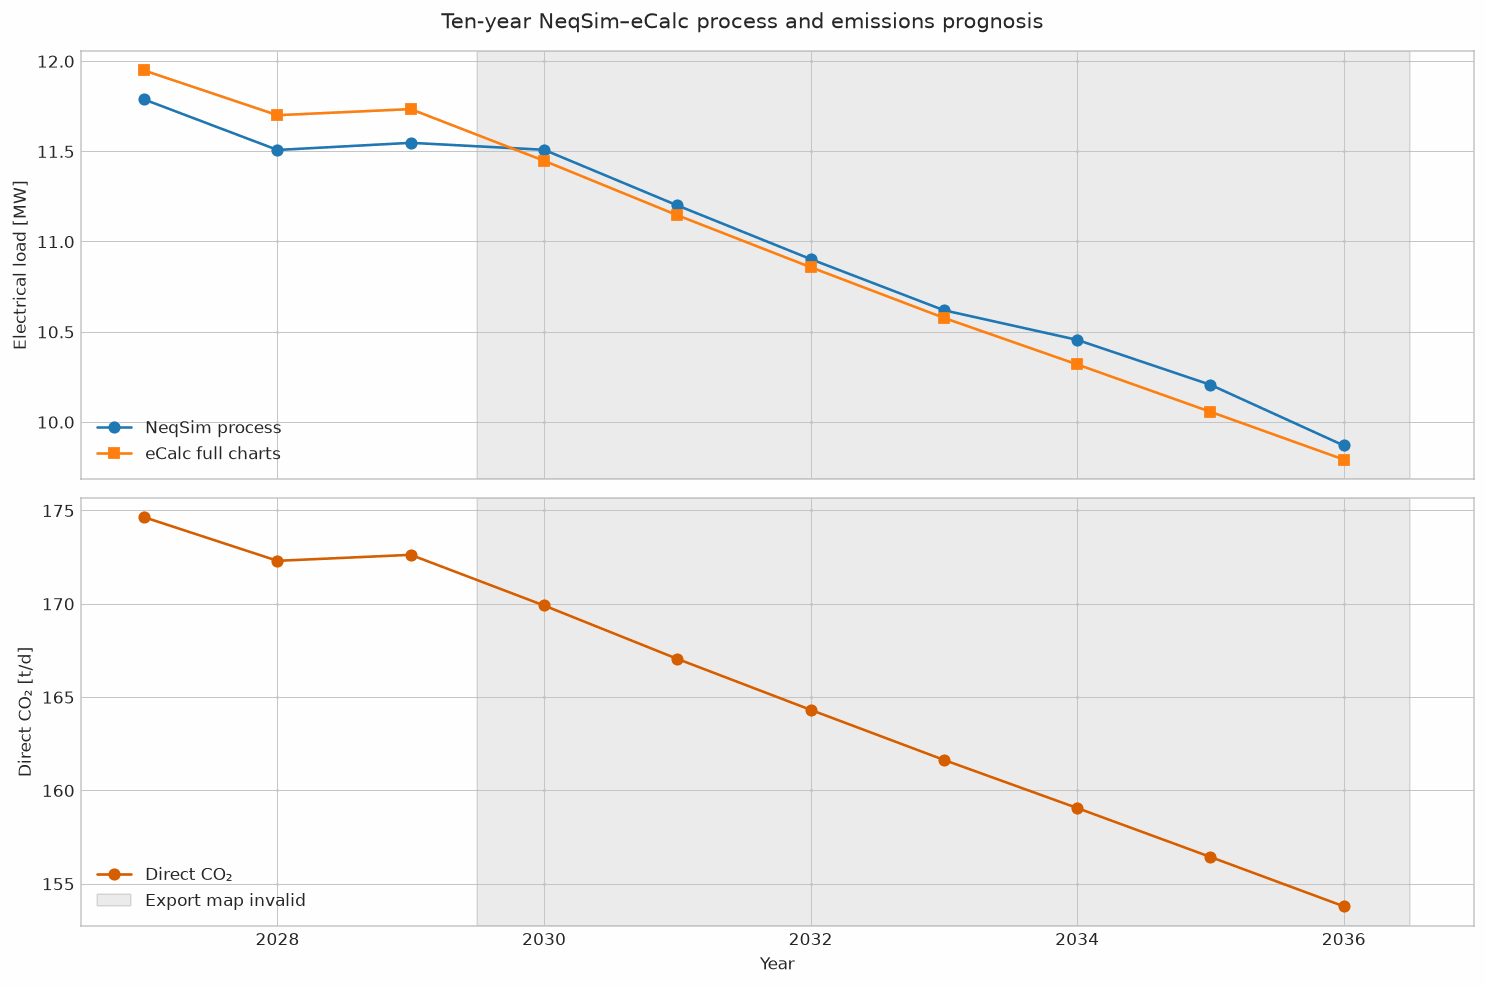

In [28]:
figure, axes = plt.subplots(2, 1, figsize=(12.0, 8.0), sharex=True)
plot_years = pd.to_datetime(process_comparison["Date"]).dt.year
axes[0].plot(
    plot_years,
    process_comparison["NeqSim direct load [MW]"],
    marker="o",
    label="NeqSim process",
)
axes[0].plot(
    plot_years,
    process_comparison["eCalc chart load [MW]"],
    marker="s",
    label="eCalc full charts",
)
axes[0].set_ylabel("Electrical load [MW]")
axes[0].legend()

axes[1].plot(
    plot_years,
    process_comparison["eCalc CO₂ [t/d]"],
    marker="o",
    color=COLORS["gas"],
    label="Direct CO₂",
)
invalid_mask = ~process_comparison["eCalc export map valid"]
if invalid_mask.any():
    first_invalid_year = plot_years[invalid_mask].iloc[0]
    final_plot_year = plot_years.iloc[-1]
    for axis in axes:
        axis.axvspan(
            first_invalid_year - 0.5,
            final_plot_year + 0.5,
            color="gray",
            alpha=0.15,
            label="Export map invalid",
        )
axes[1].set(
    xlabel="Year",
    ylabel="Direct CO₂ [t/d]",
)
axes[1].legend()
figure.suptitle("Ten-year NeqSim–eCalc process and emissions prognosis")
figure.tight_layout()
plt.show()

## 15. Hourly process load for offshore energy simulation

A 14-day profile combines production variation with the NeqSim process interpolation. The process
load is not a generic demand curve: each hourly value originates from the solved separation and
compression study.

The bus balance is:

$$
P_{\mathrm{wind}} + P_{\mathrm{battery,dis}}
+ P_{\mathrm{GT}}
=
P_{\mathrm{process}} + P_{\mathrm{battery,ch}}
$$

The firm gas turbine remains available for low-wind periods.

In [29]:
STUDY_HOURS = 14 * 24
TIME_STEP_H = 1.0
hours = np.arange(STUDY_HOURS, dtype=float)
rng = np.random.default_rng(20260727)

hourly_feed_factor = (
    0.84
    + 0.07 * np.sin(2.0 * np.pi * hours / 72.0)
    + 0.025 * np.sin(2.0 * np.pi * hours / 24.0)
)
hourly_feed_factor = np.clip(hourly_feed_factor, 0.70, 0.95)
hourly_compressor_power_mw = np.interp(
    hourly_feed_factor,
    process_sweep["Feed factor"],
    process_sweep["Compressor power [MW]"],
)
hourly_process_load_mw = (
    hourly_compressor_power_mw + FIXED_UTILITY_LOAD_MW
)

raw_wind = (
    0.54
    + 0.27 * np.sin(2.0 * np.pi * (hours - 18.0) / 96.0)
    + 0.16 * np.sin(2.0 * np.pi * hours / 27.0)
    + 0.08 * rng.normal(size=STUDY_HOURS)
)
wind_capacity_factor = np.convolve(
    np.clip(raw_wind, 0.02, 0.98),
    np.ones(5) / 5.0,
    mode="same",
)
WIND_CAPACITY_MW = 20.0
wind_speed_ms = 3.0 + 9.0 * np.cbrt(wind_capacity_factor)

WindFarm = jneqsim.process.equipment.powergeneration.WindFarm


def make_wind_farm(name, installed_capacity_mw):
    wind_farm = WindFarm(name, 5)
    wind_farm.setRatedPowerPerTurbine(
        installed_capacity_mw / 5.0 * 1.0e6
    )
    wind_farm.setRotorDiameter(150.0)
    wind_farm.setHubHeight(110.0)
    wind_farm.setCutInSpeed(3.0)
    wind_farm.setRatedSpeed(12.0)
    wind_farm.setCutOutSpeed(25.0)
    wind_farm.setWakeLossFactor(0.08)
    wind_farm.setAvailabilityFactor(0.97)
    wind_farm.setElectricalLossFactor(0.04)
    return wind_farm


profile_wind_farm = make_wind_farm(
    "profile wind farm",
    WIND_CAPACITY_MW,
)
wind_available_mw = np.array(
    [
        profile_wind_farm.calculateTurbinePower(float(speed))
        * profile_wind_farm.getNumberOfTurbines()
        / 1.0e6
        for speed in wind_speed_ms
    ]
)

hourly_profile = pd.DataFrame(
    {
        "Hour": hours,
        "Feed factor": hourly_feed_factor,
        "Compressor power [MW]": hourly_compressor_power_mw,
        "Total process load [MW]": hourly_process_load_mw,
        "Wind speed [m/s]": wind_speed_ms,
        "Wind available [MW]": wind_available_mw,
    }
)
display(hourly_profile.describe().round(4))

,Hour,Feed factor,Compressor power [MW],Total process load [MW],Wind speed [m/s],Wind available [MW]
count,336.0000,336.0000,336.0000,336.0000,336.0000,336.0000
mean,167.5000,0.8437,3.3058,11.3058,10.1849,10.8614
std,97.1391,0.0525,0.1320,0.1320,1.0948,4.3850
min,0.0000,0.7728,3.1322,11.1322,7.3251,2.2197
25%,83.7500,0.7867,3.1619,11.1619,9.5040,7.5482
50%,167.5000,0.8526,3.3266,11.3266,10.3628,10.9503
75%,251.2500,0.8937,3.4311,11.4311,11.0778,14.4606
max,335.0000,0.9072,3.4689,11.4689,11.8651,19.1142


## 16. Native NeqSim wind and firm-generation dispatch

NeqSim's released `OffshoreEnergySystem` and `WindFarm` allocate wind first and firm gas generation
second. Each hourly process demand is applied to the native dispatcher. The interval history
retains wind availability, delivery, curtailment, battery delivery, gas generation, unmet demand,
and emissions-rate bookkeeping.

In [30]:
OffshoreEnergySystem = (
    jneqsim.process.equipment.powergeneration.OffshoreEnergySystem
)
BatteryStorage = jneqsim.process.equipment.battery.BatteryStorage

GT_FIRM_CAPACITY_MW = 22.4
positive_intensity = positive_curve["CO₂ intensity [kg/MWh]"]
GT_SCREENING_FACTOR_KG_MWH = float(positive_intensity.median())


def run_native_dispatch(
    name,
    wind_speeds_ms,
    installed_wind_capacity_mw,
    battery_capacity_mwh=0.0,
):
    wind_farm = make_wind_farm(
        f"{name} wind farm",
        installed_wind_capacity_mw,
    )
    energy_system = OffshoreEnergySystem(name)
    energy_system.setWindFarm(wind_farm)
    energy_system.setGasTurbineCapacity(
        GT_FIRM_CAPACITY_MW * 1.0e6
    )
    energy_system.setGasTurbineMinLoad(0.0)
    energy_system.setGasTurbineEfficiency(0.35)
    energy_system.setCO2EmissionFactor(
        GT_SCREENING_FACTOR_KG_MWH / 1000.0
    )
    energy_system.setTimeStepHours(TIME_STEP_H)

    battery = None
    if battery_capacity_mwh > 0.0:
        battery = BatteryStorage(
            f"{name} battery",
            battery_capacity_mwh * 1.0e6,
        )
        battery.setStateOfCharge(0.0)
        energy_system.setBatteryStorage(battery)

    rows = []
    for index, (wind_speed, demand_mw) in enumerate(
        zip(wind_speeds_ms, hourly_process_load_mw)
    ):
        wind_farm.setWindSpeed(float(wind_speed))
        energy_system.setTotalPowerDemand(float(demand_mw) * 1.0e6)
        energy_system.run()
        history = energy_system.getDispatchHistory()
        result = history.get(history.size() - 1)
        wind_available = float(result.get("windAvailable_MW"))
        wind_delivered = float(result.get("windDelivered_MW"))
        curtailed = float(result.get("curtailed_MW"))
        battery_discharge = float(result.get("batteryDelivered_MW"))
        battery_charge = max(
            0.0,
            wind_available - wind_delivered - curtailed,
        )
        gas_mw = float(result.get("gasTurbineDelivered_MW"))
        served_mw = wind_delivered + battery_discharge + gas_mw
        rows.append(
            {
                "Hour": float(index),
                "Demand [MW]": float(demand_mw),
                "Wind [MW]": wind_delivered + battery_charge,
                "Wind curtailed [MW]": curtailed,
                "Battery charge [MW]": battery_charge,
                "Battery discharge [MW]": battery_discharge,
                "SOC [MWh]": (
                    0.0
                    if battery is None
                    else battery.getStateOfCharge() / 1.0e6
                ),
                "Gas [MW]": gas_mw,
                "Unmet [MW]": max(
                    0.0,
                    float(demand_mw) - served_mw,
                ),
            }
        )
    return pd.DataFrame(rows)


gas_only_dispatch = run_native_dispatch(
    "gas only",
    np.zeros(STUDY_HOURS),
    0.0,
)
wind_gas_dispatch = run_native_dispatch(
    "wind plus gas",
    wind_speed_ms,
    WIND_CAPACITY_MW,
)
print("Native NeqSim dispatch completed for two scenarios.")

Native NeqSim dispatch completed for two scenarios.


## 17. Native NeqSim battery dispatch

The battery uses NeqSim's `BatteryStorage` state and the native `OffshoreEnergySystem` dispatch.
It charges only from otherwise curtailed wind and discharges before the gas turbine. NeqSim 3.16
applies its internal 95% charge and discharge efficiencies. The dispatch is operational rather
than an economic optimizer.

In [31]:
BATTERY_CAPACITY_MWH = 40.0
BATTERY_CHARGE_EFFICIENCY = 0.95
BATTERY_DISCHARGE_EFFICIENCY = 0.95


def run_battery_dispatch(
    wind_speeds_ms,
    battery_capacity_mwh,
    installed_wind_capacity_mw=WIND_CAPACITY_MW,
):
    return run_native_dispatch(
        "wind battery gas",
        wind_speeds_ms,
        installed_wind_capacity_mw,
        battery_capacity_mwh,
    )


wind_battery_dispatch = run_battery_dispatch(
    wind_speed_ms,
    BATTERY_CAPACITY_MWH,
)
display(wind_battery_dispatch.head(12).round(4))

,Hour,Demand [MW],Wind [MW],Wind curtailed [MW],Battery charge [MW],Battery discharge [MW],SOC [MWh],Gas [MW],Unmet [MW]
0,0.0,11.2941,3.2045,0.0,0.0,0.0,0.0,8.0896,0.0
1,1.0,11.3266,4.2069,0.0,0.0,0.0,0.0,7.1197,0.0
2,2.0,11.3573,5.8861,0.0,0.0,0.0,0.0,5.4712,0.0
3,3.0,11.3856,6.8683,0.0,0.0,0.0,0.0,4.5173,0.0
4,4.0,11.4104,7.7196,0.0,0.0,0.0,0.0,3.6908,0.0
5,5.0,11.4311,7.7794,0.0,0.0,0.0,0.0,3.6517,0.0
6,6.0,11.4470,8.7470,0.0,0.0,0.0,0.0,2.7000,0.0
7,7.0,11.4602,8.8512,0.0,0.0,0.0,0.0,2.6090,0.0
8,8.0,11.4673,8.5361,0.0,0.0,0.0,0.0,2.9312,0.0
9,9.0,11.4689,8.7364,0.0,0.0,0.0,0.0,2.7326,0.0


In [32]:
def add_turbine_accounting(dispatch):
    result = dispatch.copy()
    result["Fuel [Sm³/d]"] = np.interp(
        result["Gas [MW]"],
        turbine_curve["Power [MW]"],
        turbine_curve["Fuel [Sm³/d]"],
    )
    result["CO₂ [kg/h]"] = np.interp(
        result["Gas [MW]"],
        turbine_curve["Power [MW]"],
        turbine_curve["CO₂ [kg/h]"],
    )
    return result


dispatches = {
    "Gas turbines only": add_turbine_accounting(
        gas_only_dispatch
    ),
    "Wind + gas turbines": add_turbine_accounting(
        wind_gas_dispatch
    ),
    "Wind + 40 MWh battery + gas": add_turbine_accounting(
        wind_battery_dispatch
    ),
}


def dispatch_metrics(name, dispatch):
    return {
        "Scenario": name,
        "Load [MWh]": dispatch["Demand [MW]"].sum(),
        "Wind used [MWh]": dispatch["Wind [MW]"].sum(),
        "Wind curtailed [MWh]": dispatch[
            "Wind curtailed [MW]"
        ].sum(),
        "Battery charge [MWh]": dispatch[
            "Battery charge [MW]"
        ].sum(),
        "Battery discharge [MWh]": dispatch[
            "Battery discharge [MW]"
        ].sum(),
        "Gas generation [MWh]": dispatch["Gas [MW]"].sum(),
        "Fuel [million Sm³]": (
            dispatch["Fuel [Sm³/d]"].sum() / 24.0 / 1.0e6
        ),
        "Direct CO₂ [t]": dispatch["CO₂ [kg/h]"].sum() / 1000.0,
        "Peak gas [MW]": dispatch["Gas [MW]"].max(),
        "P95 gas ramp [MW/h]": np.percentile(
            np.abs(np.diff(dispatch["Gas [MW]"])),
            95.0,
        ),
        "Unmet [MWh]": dispatch["Unmet [MW]"].sum(),
    }


dispatch_summary = pd.DataFrame(
    [
        dispatch_metrics(name, dispatch)
        for name, dispatch in dispatches.items()
    ]
)
baseline_co2_t = dispatch_summary.loc[
    dispatch_summary["Scenario"] == "Gas turbines only",
    "Direct CO₂ [t]",
].iloc[0]
dispatch_summary["CO₂ reduction [%]"] = 100.0 * (
    1.0 - dispatch_summary["Direct CO₂ [t]"] / baseline_co2_t
)
display(dispatch_summary.round(4))

,Scenario,Load [MWh],Wind used [MWh],Wind curtailed [MWh],Battery charge [MWh],Battery discharge [MWh],Gas generation [MWh],Fuel [million Sm³],Direct CO₂ [t],Peak gas [MW],P95 gas ramp [MW/h],Unmet [MWh],CO₂ reduction [%]
0,Gas turbines only,3798.7328,0.0000,0.0000,0.0000,0.0000,3798.7328,0.9018,2359.8537,11.4689,0.0325,0.0,0.0000
1,Wind + gas turbines,3798.7328,2874.1585,252.3306,0.0000,0.0000,924.5743,0.2685,702.7075,9.2768,1.0741,0.0,70.2224
2,Wind + 40 MWh battery + gas,3798.7328,3047.8050,78.6841,173.6465,122.4988,802.0755,0.2316,606.1607,9.2768,1.0255,0.0,74.3136


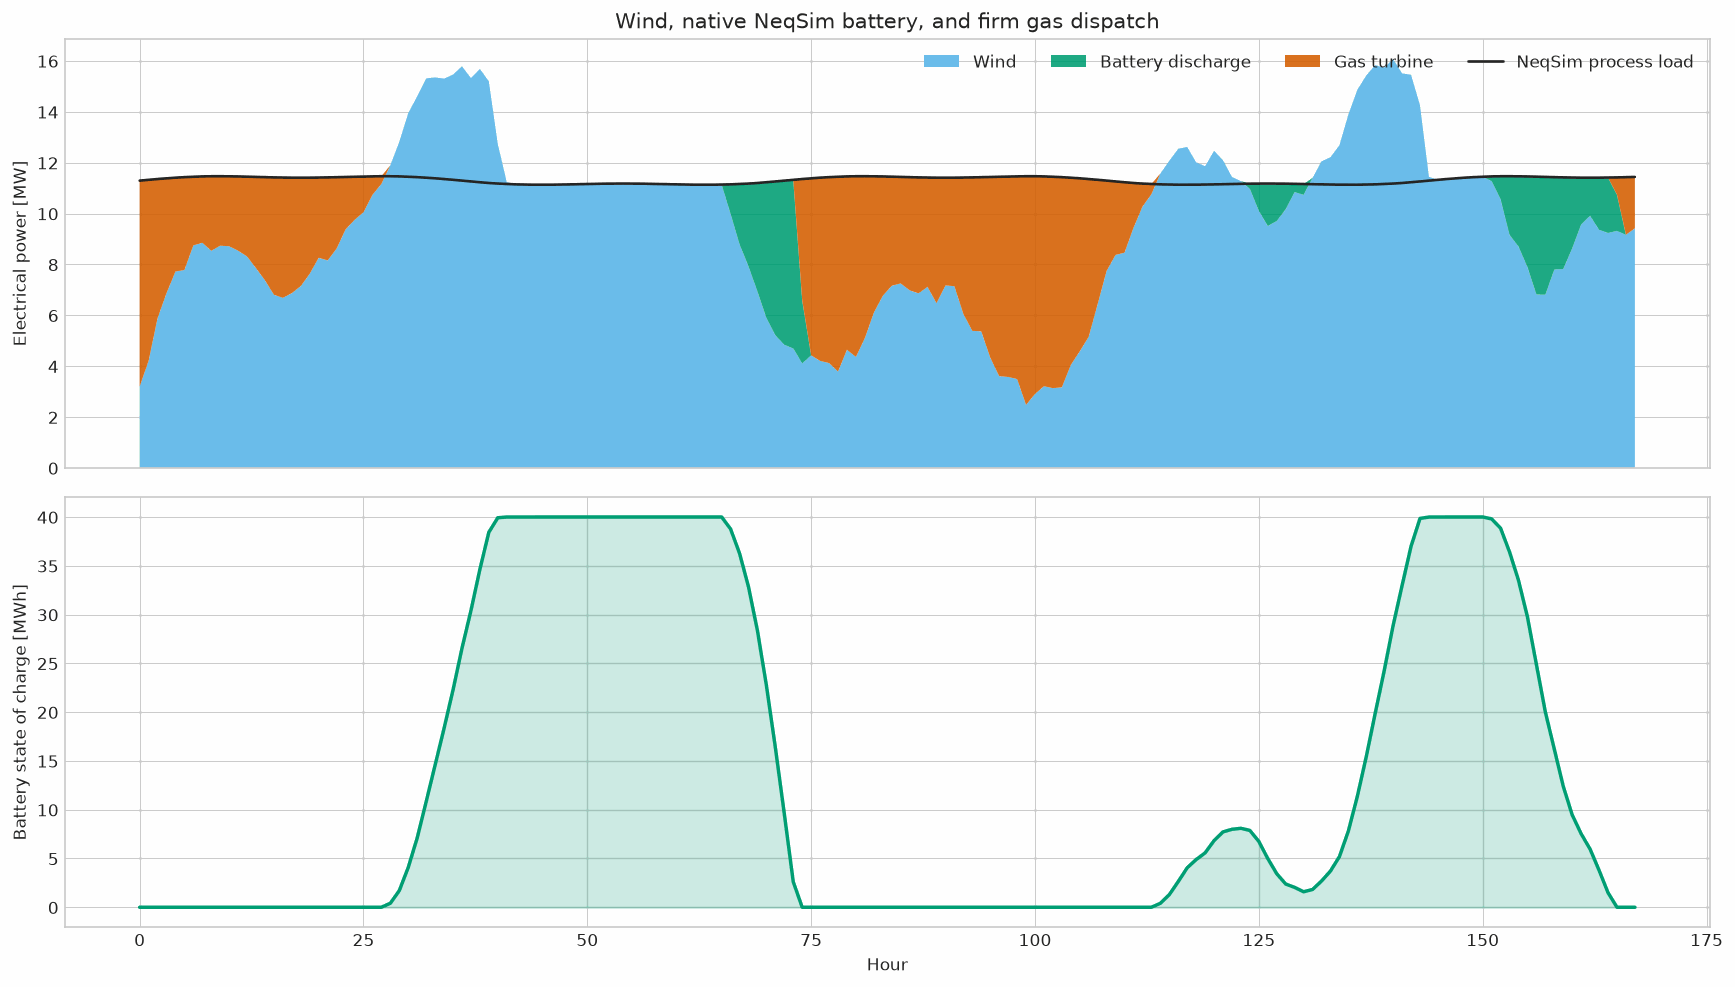

In [33]:
display_window = slice(0, 168)
plotted = dispatches["Wind + 40 MWh battery + gas"].iloc[
    display_window
]
figure, axes = plt.subplots(2, 1, figsize=(14.0, 8.0), sharex=True)
axes[0].stackplot(
    plotted["Hour"],
    plotted["Wind [MW]"],
    plotted["Battery discharge [MW]"],
    plotted["Gas [MW]"],
    labels=["Wind", "Battery discharge", "Gas turbine"],
    colors=[
        COLORS["wind"],
        COLORS["battery"],
        COLORS["gas"],
    ],
    alpha=0.88,
)
axes[0].plot(
    plotted["Hour"],
    plotted["Demand [MW]"],
    color=COLORS["load"],
    linewidth=1.5,
    label="NeqSim process load",
)
axes[0].set_ylabel("Electrical power [MW]")
axes[0].legend(ncol=4, loc="upper right")
axes[0].set_title("Wind, native NeqSim battery, and firm gas dispatch")

axes[1].plot(
    plotted["Hour"],
    plotted["SOC [MWh]"],
    color=COLORS["battery"],
    linewidth=2.0,
)
axes[1].fill_between(
    plotted["Hour"],
    0.0,
    plotted["SOC [MWh]"],
    color=COLORS["battery"],
    alpha=0.20,
)
axes[1].set(
    xlabel="Hour",
    ylabel="Battery state of charge [MWh]",
)
figure.tight_layout()
plt.show()

## 18. eCalc accounting for the hybrid dispatch

The detailed process model remains the source of demand. After NeqSim allocates wind and battery
energy, only the residual gas-turbine load is passed to this eCalc case. This avoids double
counting compressors while preserving eCalc's fuel and emissions bookkeeping.

The hybrid eCalc case therefore answers: *Given the NeqSim-resolved residual gas demand, how much
fuel and direct CO₂ does the installation account accumulate?*

In [34]:
hybrid_dispatch = dispatches[
    "Wind + 40 MWh battery + gas"
].copy()
hybrid_dates = pd.date_range(
    "2027-01-01",
    periods=STUDY_HOURS + 1,
    freq="h",
)
hybrid_profile = pd.DataFrame(
    {
        "Dates": hybrid_dates.strftime("%Y-%m-%d %H:%M:%S"),
        "RESIDUAL_GT_MW": np.append(
            hybrid_dispatch["Gas [MW]"].to_numpy(),
            hybrid_dispatch["Gas [MW]"].iloc[-1],
        ),
        "HC_EXPORT_EQ_SM3D": np.append(
            np.interp(
                hourly_feed_factor,
                forecast_factors[::-1],
                forecast_profile[
                    "HC_EXPORT_EQ_SM3D"
                ].to_numpy()[::-1],
            ),
            forecast_profile["HC_EXPORT_EQ_SM3D"].iloc[-1],
        ),
    }
)
hybrid_profile.to_csv(
    ARTIFACT_DIRECTORY / "hybrid_dispatch.csv",
    index=False,
)

hybrid_model = {
    "START": "2027-01-01 00:00:00",
    "END": str(hybrid_dates[-1]),
    "TIME_SERIES": [
        {
            "NAME": "SIM",
            "FILE": "hybrid_dispatch.csv",
            "TYPE": "DEFAULT",
        }
    ],
    "FACILITY_INPUTS": [
        {
            "NAME": "neqsim_titan250_genset",
            "FILE": "neqsim_titan250_genset.csv",
            "TYPE": "ELECTRICITY2FUEL",
        }
    ],
    "FUEL_TYPES": ecalc_process_model["FUEL_TYPES"],
    "INSTALLATIONS": [
        {
            "NAME": "Hybrid offshore installation",
            "HCEXPORT": "SIM;HC_EXPORT_EQ_SM3D",
            "FUEL": "neqsim_fuel_gas",
            "GENERATORSETS": [
                {
                    "NAME": "Residual TITAN 250 generation",
                    "ELECTRICITY2FUEL": (
                        "neqsim_titan250_genset"
                    ),
                    "CATEGORY": "TURBINE-GENERATOR",
                    "CONSUMERS": [
                        {
                            "NAME": "Residual gas demand",
                            "CATEGORY": "BASE-LOAD",
                            "ENERGY_USAGE_MODEL": {
                                "TYPE": "DIRECT",
                                "LOAD": "SIM;RESIDUAL_GT_MW",
                            },
                        }
                    ],
                }
            ],
        }
    ],
}
hybrid_model_path = ARTIFACT_DIRECTORY / "hybrid_model.yaml"
hybrid_model_path.write_text(
    yaml.safe_dump(
        hybrid_model,
        sort_keys=False,
        width=100,
    ),
    encoding="utf-8",
)
print(hybrid_model_path.read_text(encoding="utf-8"))

START: '2027-01-01 00:00:00'
END: '2027-01-15 00:00:00'
TIME_SERIES:
- NAME: SIM
  FILE: hybrid_dispatch.csv
  TYPE: DEFAULT
FACILITY_INPUTS:
- NAME: neqsim_titan250_genset
  FILE: neqsim_titan250_genset.csv
  TYPE: ELECTRICITY2FUEL
FUEL_TYPES:
- NAME: neqsim_fuel_gas
  EMISSIONS:
  - NAME: CO2
    FACTOR: 2.6167504555566836
INSTALLATIONS:
- NAME: Hybrid offshore installation
  HCEXPORT: SIM;HC_EXPORT_EQ_SM3D
  FUEL: neqsim_fuel_gas
  GENERATORSETS:
  - NAME: Residual TITAN 250 generation
    ELECTRICITY2FUEL: neqsim_titan250_genset
    CATEGORY: TURBINE-GENERATOR
    CONSUMERS:
    - NAME: Residual gas demand
      CATEGORY: BASE-LOAD
      ENERGY_USAGE_MODEL:
        TYPE: DIRECT
        LOAD: SIM;RESIDUAL_GT_MW



In [35]:
ecalc_hybrid_results = run_ecalc(
    hybrid_model_path,
    ARTIFACT_DIRECTORY / "hybrid_output",
    "hybrid_results",
)


def unique_column(dataframe, prefix):
    matches = [
        column
        for column in dataframe.columns
        if column.startswith(prefix)
    ]
    if len(matches) != 1:
        raise KeyError(f"Expected one {prefix} column: {matches}")
    return matches[0]


hybrid_power_column = unique_column(
    ecalc_hybrid_results,
    "hybrid_model.power[",
)
hybrid_co2_rate_column = unique_column(
    ecalc_hybrid_results,
    "hybrid_model.co2.rate[",
)
hybrid_co2_cumulative_column = unique_column(
    ecalc_hybrid_results,
    "hybrid_model.co2.cumulative[",
)

hybrid_rows = min(STUDY_HOURS, len(ecalc_hybrid_results))
hybrid_comparison = pd.DataFrame(
    {
        "Hour": np.arange(hybrid_rows),
        "NeqSim residual GT [MW]": hybrid_dispatch[
            "Gas [MW]"
        ].iloc[:hybrid_rows].to_numpy(),
        "eCalc generator load [MW]": ecalc_hybrid_results[
            hybrid_power_column
        ].iloc[:hybrid_rows].to_numpy(),
        "NeqSim map CO₂ [kg/h]": hybrid_dispatch[
            "CO₂ [kg/h]"
        ].iloc[:hybrid_rows].to_numpy(),
        "eCalc CO₂ [kg/h]": (
            ecalc_hybrid_results[
                hybrid_co2_rate_column
            ].iloc[:hybrid_rows].to_numpy()
            * 1000.0
            / 24.0
        ),
    }
)
hybrid_comparison["CO₂ difference [%]"] = np.where(
    hybrid_comparison["NeqSim map CO₂ [kg/h]"] > 0.0,
    100.0
    * (
        hybrid_comparison["eCalc CO₂ [kg/h]"]
        / hybrid_comparison["NeqSim map CO₂ [kg/h]"]
        - 1.0
    ),
    0.0,
)
display(hybrid_comparison.describe().round(5))


2026-07-27 09:33:29 INFO     cliecalc        eCalc™ simulation starting. Running version '13.9.0' started at '2026.07.27 09:33:29'
2026-07-27 09:33:29 INFO     cliecalc        eCalc™ simulation successful. Duration: 0:00:00.097676


,Hour,NeqSim residual GT [MW],eCalc generator load [MW],NeqSim map CO₂ [kg/h],eCalc CO₂ [kg/h],CO₂ difference [%]
count,336.00000,336.00000,336.00000,336.00000,336.00000,336.00000
mean,167.50000,2.38713,2.38713,1804.04964,1804.04964,-0.00000
std,97.13908,2.92438,2.92438,2125.54267,2125.54266,0.00008
min,0.00000,0.00000,0.00000,0.00000,0.00000,-0.00127
25%,83.75000,0.00000,0.00000,0.00000,0.00000,-0.00000
50%,167.50000,0.38205,0.38205,312.49394,312.49396,0.00000
75%,251.25000,4.51709,4.51709,3656.57823,3656.57833,0.00000
max,335.00000,9.27676,9.27676,6190.95399,6190.95417,0.00062


,Hour,NeqSim residual GT [MW],eCalc generator load [MW],NeqSim map CO₂ [kg/h],eCalc CO₂ [kg/h],CO₂ difference [%]
0,0,8.08963,8.08963,5657.09850,5657.10000,0.00003
30,30,0.00000,0.00000,0.00000,0.00000,0.00000
60,60,0.00000,0.00000,0.00000,0.00000,0.00000
91,91,4.26807,4.26807,3491.04043,3491.04042,-0.00000
121,121,0.00000,0.00000,0.00000,0.00000,0.00000
152,152,0.00000,0.00000,0.00000,0.00000,0.00000
182,182,9.18974,9.18974,6151.82154,6151.82083,-0.00001
213,213,2.54361,2.54361,2080.53011,2080.53000,-0.00001
243,243,0.00000,0.00000,0.00000,0.00000,0.00000
274,274,3.93689,3.93689,3220.14826,3220.14833,0.00000


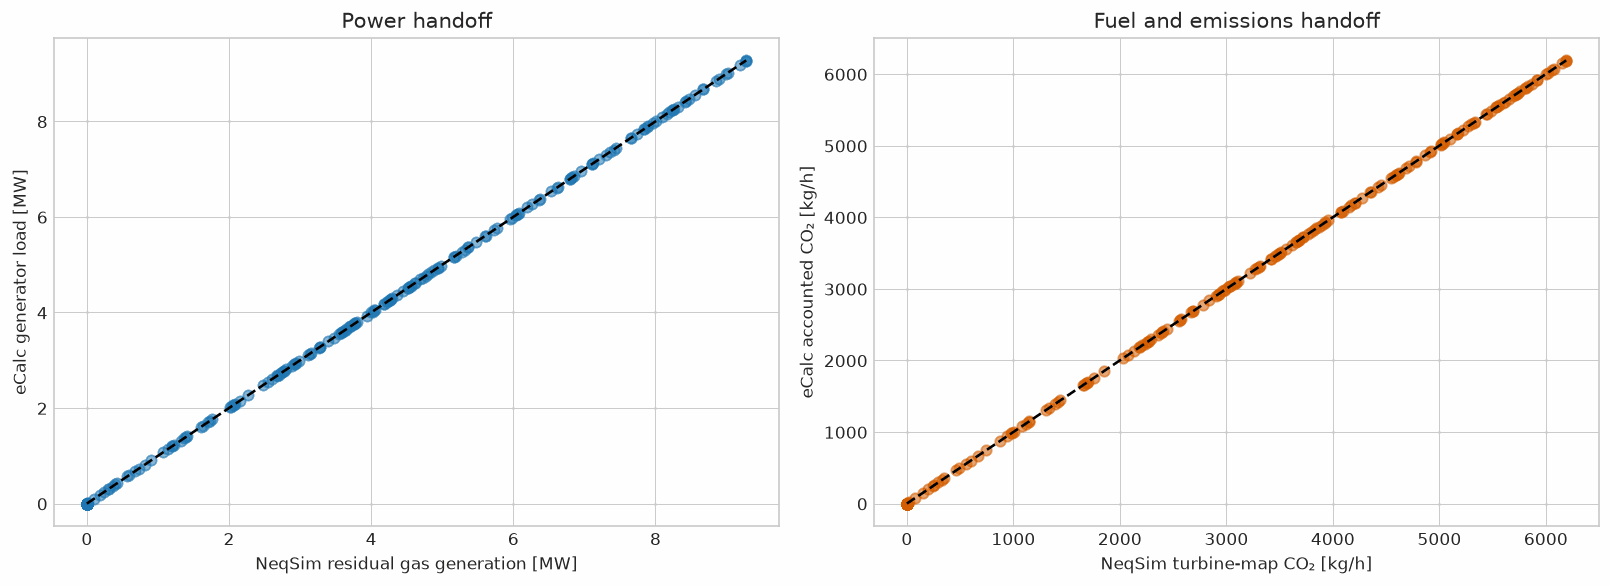

In [36]:
sample_indices = np.linspace(
    0,
    hybrid_rows - 1,
    12,
    dtype=int,
)
display(
    hybrid_comparison.iloc[sample_indices].round(5)
)

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
axes[0].scatter(
    hybrid_comparison["NeqSim residual GT [MW]"],
    hybrid_comparison["eCalc generator load [MW]"],
    alpha=0.55,
)
limit = hybrid_comparison[
    ["NeqSim residual GT [MW]", "eCalc generator load [MW]"]
].to_numpy().max()
axes[0].plot([0.0, limit], [0.0, limit], "k--")
axes[0].set(
    xlabel="NeqSim residual gas generation [MW]",
    ylabel="eCalc generator load [MW]",
    title="Power handoff",
)

axes[1].scatter(
    hybrid_comparison["NeqSim map CO₂ [kg/h]"],
    hybrid_comparison["eCalc CO₂ [kg/h]"],
    alpha=0.55,
    color=COLORS["gas"],
)
co2_limit = hybrid_comparison[
    ["NeqSim map CO₂ [kg/h]", "eCalc CO₂ [kg/h]"]
].to_numpy().max()
axes[1].plot([0.0, co2_limit], [0.0, co2_limit], "k--")
axes[1].set(
    xlabel="NeqSim turbine-map CO₂ [kg/h]",
    ylabel="eCalc accounted CO₂ [kg/h]",
    title="Fuel and emissions handoff",
)
figure.tight_layout()
plt.show()

## 19. Battery and wind sensitivity

Storage value depends on energy capacity and the amount of surplus wind. The screen below uses the
same native NeqSim 3.16 battery model for every case. It reports gas generation, curtailment, and
direct CO₂ using the NeqSim-derived turbine curve. This released battery model exposes energy
capacity and state of charge; a separate inverter power limit is therefore not imposed.

The sensitivity is an operating screen. It excludes battery degradation, CAPEX, availability,
reserve markets, start costs, and lifecycle emissions.

In [37]:
battery_capacities_mwh = [0.0, 20.0, 40.0, 80.0]
sensitivity_rows = []
for capacity_mwh in battery_capacities_mwh:
    dispatch = run_battery_dispatch(
        wind_speed_ms,
        capacity_mwh,
    )
    dispatch = add_turbine_accounting(dispatch)
    sensitivity_rows.append(
        {
            "Capacity [MWh]": capacity_mwh,
            "Gas [MWh]": dispatch["Gas [MW]"].sum(),
            "Curtailed wind [MWh]": dispatch[
                "Wind curtailed [MW]"
            ].sum(),
            "Direct CO₂ [t]": (
                dispatch["CO₂ [kg/h]"].sum() / 1000.0
            ),
            "Maximum SOC [MWh]": dispatch["SOC [MWh]"].max(),
            "Maximum discharge [MW]": dispatch[
                "Battery discharge [MW]"
            ].max(),
        }
    )

battery_sensitivity = pd.DataFrame(sensitivity_rows)
display(battery_sensitivity.round(4))

,Capacity [MWh],Gas [MWh],Curtailed wind [MWh],Direct CO₂ [t],Maximum SOC [MWh],Maximum discharge [MW]
0,0.0,924.5743,252.3306,702.7075,0.0000,0.0000
1,20.0,859.0755,161.1005,650.1161,20.0000,5.3349
2,40.0,802.0755,78.6841,606.1607,40.0000,6.6301
3,80.0,731.0631,0.0000,552.9168,71.3577,7.3068


In [38]:
wind_capacities_mw = [10.0, 14.0, 18.0, 22.0, 26.0]
wind_sensitivity_rows = []
for capacity_mw in wind_capacities_mw:
    for battery_capacity_mwh in [0.0, 40.0]:
        dispatch = run_battery_dispatch(
            wind_speed_ms,
            battery_capacity_mwh,
            capacity_mw,
        )
        dispatch = add_turbine_accounting(dispatch)
        wind_sensitivity_rows.append(
            {
                "Wind capacity [MW]": capacity_mw,
                "Battery": (
                    "None"
                    if battery_capacity_mwh == 0.0
                    else "40 MWh native battery"
                ),
                "Gas [MWh]": dispatch["Gas [MW]"].sum(),
                "Curtailed wind [MWh]": dispatch[
                    "Wind curtailed [MW]"
                ].sum(),
                "Direct CO₂ [t]": (
                    dispatch["CO₂ [kg/h]"].sum() / 1000.0
                ),
            }
        )

wind_sensitivity = pd.DataFrame(wind_sensitivity_rows)
display(wind_sensitivity.round(4))

,Wind capacity [MW],Battery,Gas [MWh],Curtailed wind [MWh],Direct CO₂ [t]
0,10.0,None,2235.4882,0.0000,1625.1726
1,10.0,40 MWh native battery,2235.4882,0.0000,1625.1726
2,14.0,None,1610.7437,0.5533,1204.2881
3,14.0,40 MWh native battery,1610.2444,0.0000,1203.8796
4,18.0,None,1098.1603,113.2677,830.7819
5,18.0,40 MWh native battery,1013.0355,0.0000,762.7488
6,22.0,None,788.4450,428.8502,601.5150
7,22.0,40 MWh native battery,664.6507,250.9796,503.2912
8,26.0,None,575.3774,841.0805,441.4418
9,26.0,40 MWh native battery,451.8212,662.0707,345.3562


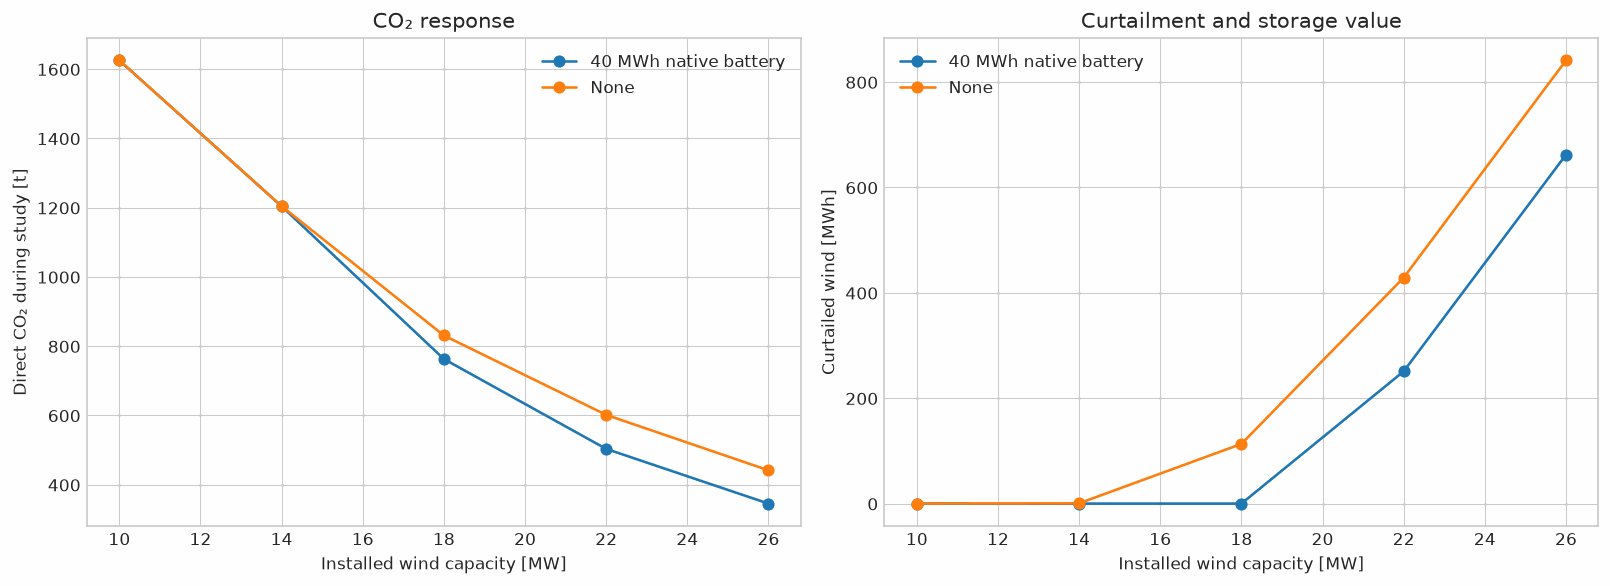

In [39]:
figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for battery_label, subset in wind_sensitivity.groupby("Battery"):
    axes[0].plot(
        subset["Wind capacity [MW]"],
        subset["Direct CO₂ [t]"],
        marker="o",
        label=battery_label,
    )
    axes[1].plot(
        subset["Wind capacity [MW]"],
        subset["Curtailed wind [MWh]"],
        marker="o",
        label=battery_label,
    )
axes[0].set(
    xlabel="Installed wind capacity [MW]",
    ylabel="Direct CO₂ during study [t]",
    title="CO₂ response",
)
axes[1].set(
    xlabel="Installed wind capacity [MW]",
    ylabel="Curtailed wind [MWh]",
    title="Curtailment and storage value",
)
for axis in axes:
    axis.legend()
figure.tight_layout()
plt.show()

## 20. Engineering validation

The acceptance checks cover:

- fluid normalization and three-phase feed behaviour;
- overall and compressor-energy closure;
- complete maps for all machines;
- surge and stonewall ordering;
- physically increasing process power with throughput;
- field-life deliverability, pressure reduction, and incremental production;
- eCalc execution, finite results, and compressor capacity outputs;
- NeqSim-to-eCalc power and emissions handoffs;
- hourly energy balance and firm-capacity coverage;
- battery state and power limits; and
- expected emissions reduction from wind and storage.

Passing checks demonstrate internal consistency for this educational case. They do not validate a
vendor map or certify an offshore power-system design.

In [40]:
checks = {}
checks["composition sums to one"] = math.isclose(
    sum(WELLSTREAM_COMPOSITION.values()),
    1.0,
    abs_tol=1.0e-12,
)
checks["feed has three phases"] = (
    named_streams["Wellstream feed"].getFluid().getNumberOfPhases() == 3
)
checks["overall mass balance closes"] = (
    abs(mass_residual_kg_h) / feed_mass_kg_h < 1.0e-10
)
checks["compressor energy balances close"] = (
    compressor_base_table["Energy residual [W]"].abs().max()
    < 1.0e-3
)
checks["all compressor powers are positive"] = (
    compressor_base_table["Power [MW]"] > 0.0
).all()
checks["all maps have seven speed lines"] = (
    map_summary["speed_lines"] == 7
).all()
checks["all maps have five points per speed"] = (
    map_summary["points"] == 35
).all()
checks["all map heads are positive"] = (
    compressor_map_data["Head [kJ/kg]"] > 0.0
).all()
checks["all map efficiencies are credible"] = (
    compressor_map_data["Efficiency [%]"].between(50.0, 90.0)
).all()
checks["design points above surge"] = (
    design_margin_table["Surge margin [%]"] > 0.0
).all()
checks["design points below stonewall"] = (
    design_margin_table["Stonewall margin [%]"] > 0.0
).all()
checks["process power rises with feed"] = np.all(
    np.diff(process_sweep["Compressor power [MW]"]) > 0.0
)
checks["field-life strategies cover every year"] = (
    len(field_life_results) == 2 * len(FIELD_YEARS)
)
checks["reduced inlet pressure never increases"] = np.all(
    np.diff(REDUCED_HP_PRESSURE_BARA) <= 0.0
)
checks["pressure reduction gives nonnegative uplift"] = (
    field_life_comparison["Production uplift [%]"] >= -1.0e-10
).all()
checks["late-life production uplift exceeds 20 percent"] = (
    field_life_comparison["Production uplift [%]"].iloc[-1] > 20.0
)
checks["cumulative incremental production is positive"] = (
    field_life_comparison[
        "Cumulative incremental feed [Mt]"
    ].iloc[-1]
    > 0.0
)
checks["eCalc process results are finite"] = np.isfinite(
    ecalc_process_results.select_dtypes(include=[np.number])
).all().all()
checks["eCalc process power is positive"] = (
    process_comparison["eCalc chart load [MW]"] > 0.0
).all()
checks["median process power difference below 8 percent"] = (
    valid_process_comparison[
        "Power difference [%]"
    ].abs().median()
    < 8.0
)
checks["eCalc flags the expected export retrofit"] = (
    0
    < process_comparison["eCalc export map valid"].sum()
    < len(process_comparison)
)
checks["eCalc exposes all three capacity results"] = (
    len(ecalc_capacity_table) == 3
)

for scenario_name, dispatch in dispatches.items():
    supply_mw = (
        dispatch["Wind [MW]"]
        + dispatch["Battery discharge [MW]"]
        + dispatch["Gas [MW]"]
    )
    demand_plus_charge_mw = (
        dispatch["Demand [MW]"]
        + dispatch["Battery charge [MW]"]
    )
    checks[f"{scenario_name}: hourly energy balance"] = np.allclose(
        supply_mw,
        demand_plus_charge_mw,
        atol=1.0e-7,
    )
    checks[f"{scenario_name}: no unmet demand"] = (
        dispatch["Unmet [MW]"].max() < 1.0e-9
    )
    checks[f"{scenario_name}: gas within firm capacity"] = (
        dispatch["Gas [MW]"].max() <= GT_FIRM_CAPACITY_MW + 1.0e-9
    )

checks["battery SOC lower bound"] = (
    wind_battery_dispatch["SOC [MWh]"].min() >= -1.0e-9
)
checks["battery SOC upper bound"] = (
    wind_battery_dispatch["SOC [MWh]"].max()
    <= BATTERY_CAPACITY_MWH + 1.0e-9
)
checks["battery both charges and discharges"] = (
    wind_battery_dispatch["Battery charge [MW]"].max() > 0.0
    and wind_battery_dispatch["Battery discharge [MW]"].max() > 0.0
)
checks["wind reduces gas generation"] = (
    dispatch_summary.loc[
        dispatch_summary["Scenario"] == "Wind + gas turbines",
        "Gas generation [MWh]",
    ].iloc[0]
    < dispatch_summary.loc[
        dispatch_summary["Scenario"] == "Gas turbines only",
        "Gas generation [MWh]",
    ].iloc[0]
)
checks["battery reduces gas generation further"] = (
    dispatch_summary.loc[
        dispatch_summary["Scenario"]
        == "Wind + 40 MWh battery + gas",
        "Gas generation [MWh]",
    ].iloc[0]
    < dispatch_summary.loc[
        dispatch_summary["Scenario"] == "Wind + gas turbines",
        "Gas generation [MWh]",
    ].iloc[0]
)
checks["hybrid power handoff within CSV precision"] = np.allclose(
    hybrid_comparison["NeqSim residual GT [MW]"],
    hybrid_comparison["eCalc generator load [MW]"],
    atol=1.0e-5,
)
positive_hybrid = (
    hybrid_comparison["NeqSim map CO₂ [kg/h]"] > 1.0e-8
)
checks["hybrid CO2 handoff within two percent"] = (
    hybrid_comparison.loc[
        positive_hybrid,
        "CO₂ difference [%]",
    ].abs().max()
    < 2.0
)

validation_table = pd.DataFrame(
    [
        {"Validation check": name, "Passed": bool(passed)}
        for name, passed in checks.items()
    ]
)
display(validation_table)
failed_checks = validation_table.loc[
    ~validation_table["Passed"],
    "Validation check",
].tolist()
assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(validation_table)} engineering checks passed.")

All 38 engineering checks passed.


,Validation check,Passed
0,composition sums to one,True
1,feed has three phases,True
2,overall mass balance closes,True
3,compressor energy balances close,True
4,all compressor powers are positive,True
5,all maps have seven speed lines,True
6,all maps have five points per speed,True
7,all map heads are positive,True
8,all map efficiencies are credible,True
9,design points above surge,True


## 21. Consolidated decision view

The practical interpretation is:

1. **Use NeqSim for physical load drivers.** Phase split, flash-gas generation, compression ratio,
   gas composition, head, power, and map feasibility must originate in the process model.
2. **Transfer complete maps when equipment constraints matter.** A rate–power table cannot retain
   speed, surge, stonewall, or anti-surge recirculation behaviour.
3. **Use NeqSim energy simulation for short-time allocation.** Wind priority, firm gas capacity,
   battery power, efficiency, and state of charge are explicit.
4. **Use eCalc for transparent installation accounting.** Component hierarchy, generator fuel,
   cumulative energy, CO₂, export intensity, recirculation loss, and capacity flags are available
   in a standard reporting model.
5. **Keep balancing capacity.** Annual wind energy displacement does not demonstrate that firm
   gas-turbine capacity can be removed.

In [41]:
annualisation_factor = 8760.0 / STUDY_HOURS
final_summary = pd.DataFrame(
    [
        {
            "Metric": "Base NeqSim process electrical load",
            "Value": (
                total_compressor_power_mw + FIXED_UTILITY_LOAD_MW
            ),
            "Unit": "MW",
        },
        {
            "Metric": "Base export-compressor power",
            "Value": compressor_base_table.loc[
                compressor_base_table["Compressor"].str.contains(
                    "HP-to-160"
                ),
                "Power [MW]",
            ].iloc[0],
            "Unit": "MW",
        },
        {
            "Metric": "Cumulative feed uplift from pressure reduction",
            "Value": field_life_comparison[
                "Cumulative incremental feed [Mt]"
            ].iloc[-1],
            "Unit": "Mt",
        },
        {
            "Metric": "End-of-study production uplift",
            "Value": field_life_comparison[
                "Production uplift [%]"
            ].iloc[-1],
            "Unit": "%",
        },
        {
            "Metric": "Generated compressor speed lines",
            "Value": int(map_summary["speed_lines"].sum()),
            "Unit": "lines across 3 maps",
        },
        {
            "Metric": "Gas-only direct CO₂, annualised",
            "Value": (
                dispatch_summary.loc[
                    dispatch_summary["Scenario"]
                    == "Gas turbines only",
                    "Direct CO₂ [t]",
                ].iloc[0]
                * annualisation_factor
                / 1000.0
            ),
            "Unit": "kt/y",
        },
        {
            "Metric": "Wind + battery direct CO₂, annualised",
            "Value": (
                dispatch_summary.loc[
                    dispatch_summary["Scenario"]
                    == "Wind + 40 MWh battery + gas",
                    "Direct CO₂ [t]",
                ].iloc[0]
                * annualisation_factor
                / 1000.0
            ),
            "Unit": "kt/y",
        },
        {
            "Metric": "Wind + battery CO₂ reduction",
            "Value": dispatch_summary.loc[
                dispatch_summary["Scenario"]
                == "Wind + 40 MWh battery + gas",
                "CO₂ reduction [%]",
            ].iloc[0],
            "Unit": "%",
        },
        {
            "Metric": "eCalc-valid export-map intervals",
            "Value": int(
                process_comparison["eCalc export map valid"].sum()
            ),
            "Unit": f"of {len(process_comparison)} intervals",
        },
        {
            "Metric": "Median eCalc vs NeqSim process-power difference",
            "Value": valid_process_comparison[
                "Power difference [%]"
            ].abs().median(),
            "Unit": "%",
        },
        {
            "Metric": "Maximum eCalc vs NeqSim hybrid CO₂ difference",
            "Value": hybrid_comparison.loc[
                positive_hybrid,
                "CO₂ difference [%]",
            ].abs().max(),
            "Unit": "%",
        },
    ]
)
display(final_summary.round(4))

,Metric,Value,Unit
0,Base NeqSim process electrical load,11.9407,MW
1,Base export-compressor power,3.2288,MW
2,Cumulative feed uplift from pressure reduction,0.8421,Mt
3,End-of-study production uplift,34.6153,%
4,Generated compressor speed lines,21.0000,lines across 3 maps
5,"Gas-only direct CO₂, annualised",61.5248,kt/y
6,"Wind + battery direct CO₂, annualised",15.8035,kt/y
7,Wind + battery CO₂ reduction,74.3136,%
8,eCalc-valid export-map intervals,3.0000,of 10 intervals
9,Median eCalc vs NeqSim process-power difference,1.6188,%


## 22. Limitations

- The wellstream and production profiles are synthetic.
- Field deliverability uses a calibrated back-pressure equation; reservoir material balance,
  aquifer support, well count, tubing hydraulics, and compositional depletion are excluded.
- The pressure-reduction schedule is a scenario, not an optimized operating policy.
- Post-constraint eCalc fuel and CO₂ values are retained only to show the invalid-map flags; a
  redesigned or re-staged export compressor is required before those years can be forecast.
- SRK is used consistently, but no laboratory PVT regression is included.
- Separator residence time, carry-over, pressure drop, and mechanical sizing are excluded.
- Generated maps are early-phase maps anchored to a process design point, not vendor guarantees.
- The gas composition passed to eCalc is truncated at n-hexane because that is the supported
  composition set; the retained fraction is reported.
- Each compressor is represented as one eCalc chart stage/casing.
- Drivers, gears, motors, seal systems, vibration, torque, starts, and transient anti-surge control
  are outside the steady-state maps.
- The wind series is 14 synthetic days and should not be treated as an annual hindcast.
- The battery controller is greedy and excludes degradation, reserve, availability, and economics.
- eCalc receives residual gas generation after dispatch; wind and storage are not represented as
  eCalc equipment in the hybrid model.
- CO₂ is direct combustion only. Methane, NOₓ, Scope 2, construction, and lifecycle boundaries need
  separate assumptions.
- Results support screening and teaching only.

## 23. Suggested extensions

1. Couple the surface model to a reservoir and well model with pressure-dependent composition.
2. Replace generated maps with vendor curves while preserving the same transfer function.
3. Add molecular-weight-dependent compressor maps for field-life composition change.
4. Optimize the inlet-pressure schedule against recovery, map margins, power, and retrofit cost.
5. Model parallel trains, common anti-surge recycle, and N+1 availability.
6. Use an authorised full-year wind hindcast and production forecast.
7. Add power from shore with cable losses, availability, and grid-intensity scenarios.
8. Optimise battery energy and power against starts, efficiency, curtailment, and cost.
9. Add pumps, heating, cooling, flaring, venting, and methane emissions to eCalc.
10. Benchmark the compressor results and export an auditable decision report.

## References

- [eCalc introduction](https://equinor.github.io/ecalc/docs/about/)
- [eCalc model setup](https://equinor.github.io/ecalc/docs/about/modelling/setup/)
- [eCalc compressor charts](https://equinor.github.io/ecalc/docs/about/modelling/setup/models/compressor_modelling/compressor_charts/)
- [eCalc CLI](https://equinor.github.io/ecalc/docs/about/getting_started/cli/)
- [eCalc source repository](https://github.com/equinor/ecalc)
- [NeqSim compressor curves](https://equinor.github.io/neqsim/process/equipment/compressor_curves.html)
- [NeqSim energy time-series simulation](https://equinor.github.io/neqsim/process/energy_time_series.html)
- [NeqSim energy streams](https://equinor.github.io/neqsim/process/energy_streams.html)
- [Equinor Hywind Tampen](https://www.equinor.com/energy/hywind-tampen)